# Load Residuals EVT Analysis
## Extreme Value Theory on ARIMA-GARCH Residuals

### Executive Summary

This notebook performs a comprehensive **Extreme Value Theory (EVT)** analysis on electricity load forecast errors from seasonal ARIMA-GARCH models. The analysis focuses on understanding tail risks in forecast errors and their relationship with temperature extremes, with separate treatment of heating (HDD) and cooling (CDD) seasons.

---

### 📊 Analysis Overview

**Objective**: Quantify extreme forecast errors and their joint behavior with temperature anomalies to inform hedging strategies for electricity load risk.

**Data Source**: Pre-fitted ARIMA-GARCH residuals from `Load_Analytics.ipynb` stored in pickle files, representing forecast errors after removing seasonal patterns and autocorrelation.

**Time Period**: Filtered to heating and cooling months only:
- **HDD Months (Heating)**: November, December, January, February, March
- **CDD Months (Cooling)**: June, July, August

**Cities Analyzed**: Boston, Chicago, Dallas, Houston, Minneapolis, New York

---

### 🔬 Methodology

#### 1. **Data Preparation**
- **Load Residuals**: Filtered to HDD+CDD months, **NO sign adjustment**
  - Positive residuals = Underforecasts (actual > forecast) → need more capacity
  - Negative residuals = Overforecasts (actual < forecast) → wasted capacity
  - Consistent interpretation across all seasons

- **Temperature Residuals**: Filtered to HDD+CDD months, **sign flipped for winter**
  - Winter (HDD): Negative temp residual (colder) → flipped to positive
    - Rationale: Aligns with increased heating load when temperature drops
  - Summer (CDD): Positive temp residual (hotter) → kept positive
    - Rationale: Already aligns with increased cooling load when hot

#### 2. **Univariate EVT Analysis (Load Residuals)**
- **GPD Tail Fitting**: Generalized Pareto Distribution fitted to 95th percentile (right tail) and 5th percentile (left tail)
  - Right tail: Positive residuals (underforecasts - capacity shortfall)
  - Left tail: Negative residuals (overforecasts - wasted capacity)
  - **Declustering applied**: Ensures independence of exceedances using runs method
  
- **Key Metrics**:
  - **ξ (xi)**: Shape parameter (Extreme Value Index)
    - ξ > 0.1: Heavy-tailed (extreme events more likely)
    - 0 < ξ ≤ 0.1: Moderate tail
    - ξ ≤ 0: Light-tailed (rare extremes)
  - **σ (sigma)**: Scale parameter (magnitude of exceedances)
  - **λ (lambda)**: Exceedance rate (frequency above threshold)

- **Outputs**: 
  - `load_residuals_gpd_right_tail.csv`
  - `load_residuals_gpd_left_tail.csv`

#### 3. **Multivariate Dependence (Across Cities)**
- **Copula Analysis**: Student-t copula with 100,000 simulated scenarios
  - Captures tail dependence between load forecast errors across different cities
  - Kendall correlation used for dependence structure
  
- **Ferreira's Tail Dependence Coefficient (TDC)**:
  - Measures probability of joint extremes
  - TDC ∈ [0, 1]: 0 = independence, 1 = perfect tail dependence
  
- **Joint Exceedance Probabilities**: 
  - P(all cities exceed 95th) vs expected under independence
  - Multiplier shows how much more/less likely than independence

- **Outputs**:
  - `load_residuals_tdc_matrix.csv`
  - `load_residuals_correlation.png` (Figure 1)
  - `load_residuals_tdc.png` (Figure 2)

#### 4. **Temperature-Load Joint Analysis (Within City)**
- **Bivariate Copula**: Analyzes temp-load coupling for each city
  - Empirical CDF transformation to uniform [0,1]
  - Kendall correlation and Ferreira's TDC calculated
  
- **Joint Exceedance at 90th, 95th, 99th percentiles**:
  - P(both temp & load exceed threshold)
  - P(only load exceeds) vs P(only temp exceeds)
  - Multiplier vs independence benchmark
  
- **Interpretation**:
  - Multiplier > 1.5: Strong positive dependence (extremes cluster)
  - Multiplier 1.1-1.5: Moderate dependence
  - Multiplier < 1.1: Weak/near independence

- **Outputs**:
  - `temp_load_joint_exceedance.csv`
  - `temp_load_dependence_summary.csv`
  - `load_temp_joint_tails.png` (Figure 3: Scatter plots showing joint extremes)

#### 5. **Seasonal Analysis: HDD vs CDD**
- **Separate Analysis by Season**: Compare winter (heating) vs summer (cooling)
  - Same cities analyzed in both HDD and CDD periods
  - 95th percentile joint exceedance calculated for each season
  
- **Comparison Metrics**:
  - Kendall correlation (HDD vs CDD)
  - Tail Dependence Coefficient (TDC)
  - Joint exceedance multiplier
  - Sample size (number of days in each season)
  
- **Key Question**: Does temperature-load coupling differ by season?
  - If HDD multiplier >> CDD multiplier: Winter shows stronger joint tail risk
  - If CDD multiplier >> HDD multiplier: Summer shows stronger joint tail risk
  - Similar multipliers: Consistent risk across seasons

- **Outputs**:
  - `temp_load_seasonal_comparison.csv`
  - `hdd_cdd_comparison.png` (Figure 4: Bar charts comparing metrics)
  - `hdd_cdd_scatter_comparison.png` (Figure 5: Side-by-side scatter plots)

---

### 📈 Key Findings & Interpretation

**See outputs for specific values:**

1. **Load Forecast Tail Characteristics**:
   - Right tail (underforecasts): Shape parameters indicate tail heaviness
   - Left tail (overforecasts): Assess symmetry of forecast errors
   - Cities with ξ > 0.1 require extra capacity buffers

2. **Cross-City Dependence**:
   - High TDC (>0.5): Extreme errors tend to occur simultaneously across cities
   - Low TDC (<0.2): Cities experience extremes independently
   - Implications for portfolio diversification

3. **Temperature-Load Coupling**:
   - Strong coupling (multiplier >1.5): Temperature extremes predict load forecast failures
   - Requires joint hedging strategies (HDD/CDD derivatives + capacity reserves)
   - Weak coupling: Can manage risks separately

4. **Seasonal Differences**:
   - HDD > CDD: Winter temperature extremes more critical for load forecasting
   - CDD > HDD: Summer temperature extremes drive forecast errors
   - Informs seasonal hedging priorities

---

### 🎯 Practical Applications

1. **Capacity Planning**: Use exceedance probabilities to size reserve margins
2. **Weather Derivatives**: Design HDD/CDD contracts based on joint tail risk
3. **Forecast Improvement**: Focus modeling efforts on seasons with weak temp-load coupling
4. **Risk Management**: Quantify joint tail scenarios for stress testing
5. **Hedging Strategies**: 
   - Strong seasonal differences → season-specific hedges
   - Strong cross-city dependence → geographic diversification limited

---

### 📁 Complete Output Inventory

**CSV Files** (in `../data/processed/`):
1. `load_residuals_gpd_right_tail.csv` - GPD parameters for positive residuals
2. `load_residuals_gpd_left_tail.csv` - GPD parameters for negative residuals
3. `load_residuals_joint_tail_probabilities.csv` - Cross-city joint exceedance
4. `load_residuals_tdc_matrix.csv` - Tail dependence coefficients (city pairs)
5. `temp_load_joint_exceedance.csv` - Temp-load joint probabilities by city
6. `temp_load_dependence_summary.csv` - Summary statistics per city
7. `temp_load_seasonal_comparison.csv` - HDD vs CDD comparison

**Figures** (in `../data/images/`):
1. `load_residuals_correlation.png` - Kendall correlation heatmap (cross-city)
2. `load_residuals_tdc.png` - Tail dependence coefficient clustermap
3. `load_temp_joint_tails.png` - Scatter plots with joint extreme events
4. `hdd_cdd_comparison.png` - Bar charts comparing HDD vs CDD metrics
5. `hdd_cdd_scatter_comparison.png` - Side-by-side seasonal scatter plots

---

### 🔍 How to Interpret Results

**For Each City:**
1. Check GPD shape parameter (ξ):
   - Heavy tail (ξ > 0.1) → More frequent extreme errors
   - Light tail (ξ ≤ 0) → Rare extreme errors

2. Review temp-load multiplier:
   - >2x → Temperature extremes double the probability of load extremes
   - <1.5x → Relatively independent

3. Compare HDD vs CDD multipliers:
   - Difference >0.5x → Significant seasonal asymmetry
   - Focus hedging on season with higher multiplier

**Across Cities:**
1. TDC matrix shows which city pairs have correlated extremes
2. High TDC → Portfolio risk not diversified geographically
3. Joint exceedance probabilities inform multi-region contingency planning

## I. Setup and Data Loading

In [80]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import genpareto, t as tdist
import pickle
import warnings
warnings.filterwarnings('ignore')

# EVT and copula tools
import torch
from wxderivs import unibm, MONTH_CDD, MONTH_HDD

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [81]:
def ferreira_tail_dep_coeff(x: torch.Tensor, y: torch.Tensor) -> float:
    """Pairwise tail dependence coefficient (λ) estimator
    Ferreira, M.S., 2013. Nonparametric estimation of the tail-dependence coefficient
    """
    x1 = 1 - x
    y1 = 1 - y
    return (
        3
        - (
            1
            - torch.as_tensor(
                [
                    torch.max(x, y).mean(),
                    torch.max(y, x1).mean(),
                    torch.max(x1, y1).mean(),
                    torch.max(y1, x).mean(),
                ]
            )
            .clamp(0.5, 0.6666666666666666)
            .min()
        ).reciprocal()
    ).item()

In [82]:
# Load temperature data
with open('../data/processed/temperature_analysis_data.pkl', 'rb') as f:
    temp_data = pickle.load(f)

# Load load data
with open('../data/processed/all_analysis_data.pkl', 'rb') as f:
    load_data = pickle.load(f)

print("Temperature Data Keys:", list(temp_data.keys()))
print("\nLoad Data Keys:", list(load_data.keys()))

# Import month definitions
print(f"\nHDD Months (Heating): {MONTH_HDD}")
print(f"CDD Months (Cooling): {MONTH_CDD}")

Temperature Data Keys: ['df_boston', 'df_ny', 'df_chicago', 'df_minneapolis', 'df_houston', 'df_dallas', 'df_res', 'df_cdd_temp_res', 'df_hdd_temp_res', 'df_result', 'region_fit', 'df_tdc_temp_cdd_res', 'df_tdc_temp_hdd_res', 'dct_evi_temp_res_right', 'dct_evi_temp_res_left', 'df_evi_res_right', 'df_evi_res_left', 'boston_garch_fit', 'summary_stats', 'volatility_by_doy']

Load Data Keys: ['df_boston', 'df_ny', 'df_chicago', 'df_minneapolis', 'df_res', 'df_cdd_load_res', 'df_hdd_load_res', 'df_result', 'df_tdc_load_cdd_res', 'df_tdc_load_hdd_res', 'dct_evi_load_res_right', 'dct_evi_load_res_left', 'df_evi_res_right', 'df_evi_res_left']

HDD Months (Heating): {1, 2, 3, 11, 12}
CDD Months (Cooling): {5, 6, 7, 8, 9}


In [83]:
# Extract load residuals from ARIMA-GARCH models
# These are residuals after removing seasonal patterns and ARMA components
load_residuals = load_data['df_res'].copy()

print(f"Load residuals shape (before filtering): {load_residuals.shape}")
print(f"Date range: {load_residuals.index.min()} to {load_residuals.index.max()}")

# Filter to HDD and CDD months only
load_residuals['month'] = load_residuals.index.month
hdd_cdd_mask = load_residuals['month'].isin(list(MONTH_HDD) + list(MONTH_CDD))
load_residuals_filtered = load_residuals[hdd_cdd_mask].drop('month', axis=1)

print(f"\nLoad residuals shape (HDD+CDD months only): {load_residuals_filtered.shape}")

# Show month breakdown
months_in_data = load_residuals_filtered.index.month.value_counts().sort_index()
print(f"\nMonths included in filtered data:")
for month, count in months_in_data.items():
    season = "HDD (Heating)" if month in MONTH_HDD else "CDD (Cooling)"
    print(f"  Month {month:2d}: {count:4d} days - {season}")

# NO SIGN FLIP FOR LOAD RESIDUALS
# Load residuals kept as original: positive = underforecast, negative = overforecast
print(f"\n{'='*80}")
print(f"LOAD RESIDUALS - NO SIGN ADJUSTMENT")
print(f"{'='*80}")
print("Load residuals interpretation:")
print("  • Positive residual = Actual > Forecast (underforecast)")
print("  • Negative residual = Actual < Forecast (overforecast)")
print("  • Same interpretation for both HDD and CDD months")

winter_mask = load_residuals_filtered.index.month.isin(MONTH_HDD)
summer_mask = ~winter_mask

print(f"\nWinter days (HDD months {MONTH_HDD}): {winter_mask.sum()}")
print(f"Summer days (CDD months {MONTH_CDD}): {summer_mask.sum()}")
print(f"Total: {len(load_residuals_filtered)}")

print(f"\nCities: {load_residuals_filtered.columns.tolist()}")

# Show statistics by season
print(f"\n{'='*80}")
print(f"LOAD RESIDUALS BY SEASON")
print(f"{'='*80}")
for col in load_residuals_filtered.columns:
    winter_mean = load_residuals_filtered.loc[winter_mask, col].mean()
    summer_mean = load_residuals_filtered.loc[summer_mask, col].mean()
    print(f"\n{col}:")
    print(f"  Winter mean: {winter_mean:8.2f} MW")
    print(f"  Summer mean: {summer_mean:8.2f} MW")

# Show sample dates from each season
print(f"\n{'='*80}")
print(f"SAMPLE DATA - WINTER (HDD) MONTHS")
print(f"{'='*80}")
winter_sample = load_residuals_filtered[winter_mask].head(5)
display(winter_sample)

print(f"\n{'='*80}")
print(f"SAMPLE DATA - SUMMER (CDD) MONTHS")
print(f"{'='*80}")
summer_sample = load_residuals_filtered[summer_mask].head(5)
display(summer_sample)

print(f"\n{'='*80}")
print(f"DESCRIPTIVE STATISTICS")
print(f"{'='*80}")
print(f"\nAll months (HDD+CDD):")
display(load_residuals_filtered.describe())

Load residuals shape (before filtering): (3286, 4)
Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00

Load residuals shape (HDD+CDD months only): (2737, 4)

Months included in filtered data:
  Month  1:  279 days - HDD (Heating)
  Month  2:  254 days - HDD (Heating)
  Month  3:  279 days - HDD (Heating)
  Month  5:  279 days - CDD (Cooling)
  Month  6:  270 days - CDD (Cooling)
  Month  7:  279 days - CDD (Cooling)
  Month  8:  279 days - CDD (Cooling)
  Month  9:  270 days - CDD (Cooling)
  Month 11:  270 days - HDD (Heating)
  Month 12:  278 days - HDD (Heating)

LOAD RESIDUALS - NO SIGN ADJUSTMENT
Load residuals interpretation:
  • Positive residual = Actual > Forecast (underforecast)
  • Negative residual = Actual < Forecast (overforecast)
  • Same interpretation for both HDD and CDD months

Winter days (HDD months {1, 2, 3, 11, 12}): 1360
Summer days (CDD months {5, 6, 7, 8, 9}): 1377
Total: 2737

Cities: ['Chicago', 'Boston', 'NewYork', 'Minneapolis']

LOAD RESIDUALS BY SEAS

Load residuals shape (before filtering): (3286, 4)
Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00

Load residuals shape (HDD+CDD months only): (2737, 4)

Months included in filtered data:
  Month  1:  279 days - HDD (Heating)
  Month  2:  254 days - HDD (Heating)
  Month  3:  279 days - HDD (Heating)
  Month  5:  279 days - CDD (Cooling)
  Month  6:  270 days - CDD (Cooling)
  Month  7:  279 days - CDD (Cooling)
  Month  8:  279 days - CDD (Cooling)
  Month  9:  270 days - CDD (Cooling)
  Month 11:  270 days - HDD (Heating)
  Month 12:  278 days - HDD (Heating)

LOAD RESIDUALS - NO SIGN ADJUSTMENT
Load residuals interpretation:
  • Positive residual = Actual > Forecast (underforecast)
  • Negative residual = Actual < Forecast (overforecast)
  • Same interpretation for both HDD and CDD months

Winter days (HDD months {1, 2, 3, 11, 12}): 1360
Summer days (CDD months {5, 6, 7, 8, 9}): 1377
Total: 2737

Cities: ['Chicago', 'Boston', 'NewYork', 'Minneapolis']

LOAD RESIDUALS BY SEAS

,Chicago,Boston,NewYork,Minneapolis
date,,,,
2014-01-01,37390.096126,2900.982144,8157.543767,16897.966233
2014-01-02,6673.792606,352.923170,568.234552,1296.178904
2014-01-03,1800.294711,548.019925,373.054429,-34.102673
2014-01-04,-2753.921529,334.181736,-333.413654,-1467.174361
2014-01-05,2032.973024,-137.272829,-301.811380,1190.633649



SAMPLE DATA - SUMMER (CDD) MONTHS


,Chicago,Boston,NewYork,Minneapolis
date,,,,
2014-05-01,916.487413,38.886040,52.714422,51.229585
2014-05-02,-687.610558,-9.184225,-31.360195,-264.489161
2014-05-03,-2919.340051,-115.280085,-329.180114,-1259.641544
2014-05-04,-1101.027870,15.123493,-87.634989,-346.658261
2014-05-05,3573.347079,68.481409,259.531635,786.127707


...

,Chicago,Boston,NewYork,Minneapolis
date,,,,
2014-01-01,37390.096126,2900.982144,8157.543767,16897.966233
2014-01-02,6673.792606,352.923170,568.234552,1296.178904
2014-01-03,1800.294711,548.019925,373.054429,-34.102673
2014-01-04,-2753.921529,334.181736,-333.413654,-1467.174361
2014-01-05,2032.973024,-137.272829,-301.811380,1190.633649



SAMPLE DATA - SUMMER (CDD) MONTHS


,Chicago,Boston,NewYork,Minneapolis
date,,,,
2014-05-01,916.487413,38.886040,52.714422,51.229585
2014-05-02,-687.610558,-9.184225,-31.360195,-264.489161
2014-05-03,-2919.340051,-115.280085,-329.180114,-1259.641544
2014-05-04,-1101.027870,15.123493,-87.634989,-346.658261
2014-05-05,3573.347079,68.481409,259.531635,786.127707



DESCRIPTIVE STATISTICS

All months (HDD+CDD):


,Chicago,Boston,NewYork,Minneapolis
count,2737.000000,2737.000000,2737.000000,2737.000000
mean,-144.890503,2.280252,-1.082536,-35.389404
std,2522.446882,207.227512,601.202267,932.591009
min,-10487.065324,-1140.356431,-3251.184255,-2987.937887
25%,-1748.783110,-105.498444,-310.772914,-630.856789
50%,-310.348578,-7.251801,-23.996211,-53.286341
75%,1423.040254,95.140269,259.531635,533.766686
max,37390.096126,2900.982144,8157.543767,16897.966233


In [84]:
# Define city list
cities = load_residuals_filtered.columns.tolist()
print(f"Cities for analysis: {cities}")

# Drop any remaining NaN values (use filtered, not adjusted)
load_residuals_clean = load_residuals_filtered.dropna()
print(f"\nClean residuals shape: {load_residuals_clean.shape}")
print(f"Date range: {load_residuals_clean.index.min()} to {load_residuals_clean.index.max()}")

# Show month distribution
month_counts = load_residuals_clean.index.month.value_counts().sort_index()
print(f"\nMonth distribution:")
for month, count in month_counts.items():
    season = "HDD (Heating)" if month in MONTH_HDD else "CDD (Cooling)"
    print(f"  Month {month:2d}: {count:4d} days ({season})")

Cities for analysis: ['Chicago', 'Boston', 'NewYork', 'Minneapolis']

Clean residuals shape: (2737, 4)
Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00

Month distribution:
  Month  1:  279 days (HDD (Heating))
  Month  2:  254 days (HDD (Heating))
  Month  3:  279 days (HDD (Heating))
  Month  5:  279 days (CDD (Cooling))
  Month  6:  270 days (CDD (Cooling))
  Month  7:  279 days (CDD (Cooling))
  Month  8:  279 days (CDD (Cooling))
  Month  9:  270 days (CDD (Cooling))
  Month 11:  270 days (HDD (Heating))
  Month 12:  278 days (HDD (Heating))


### Distribution of Load Residuals by City

Visualize the empirical distribution of load forecast errors for each city to understand the shape of the data before applying EVT.

LOAD RESIDUALS DISTRIBUTION BY CITY


LOAD RESIDUALS DISTRIBUTION BY CITY


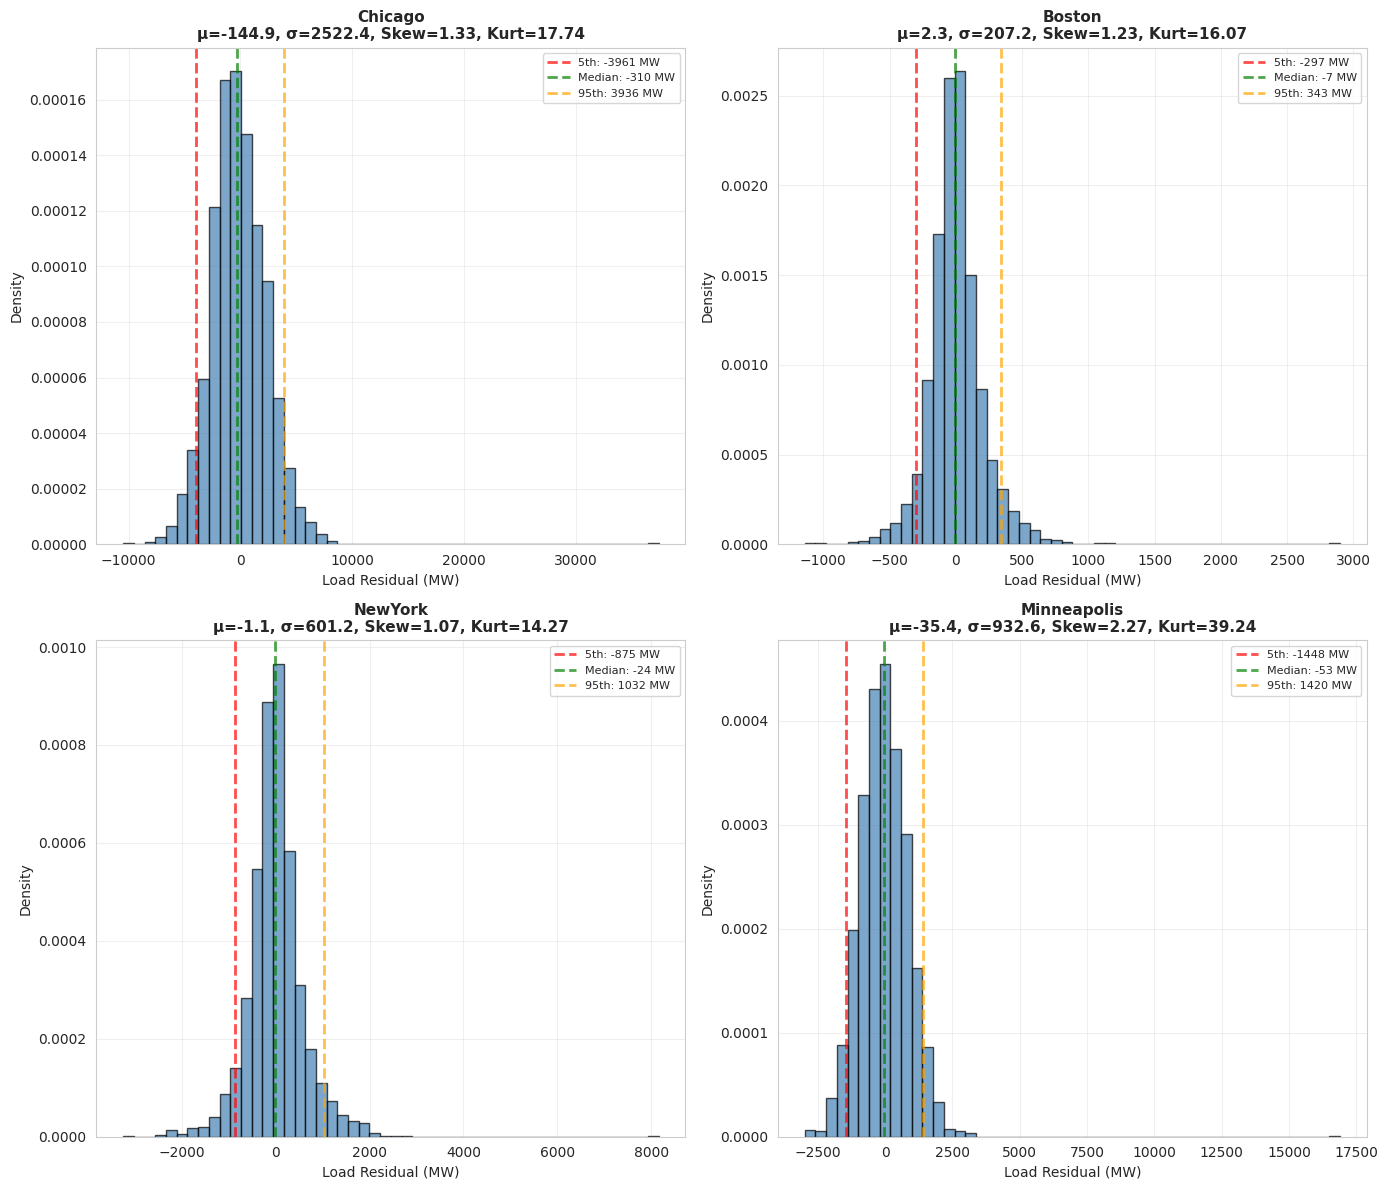


✓ Saved: ../data/images/load_residuals_histograms.png

City                  Mean        Std   Skewness   Kurtosis        Min        Max
Chicago             -144.9     2522.4       1.33      17.74   -10487.1    37390.1
Boston                 2.3      207.2       1.23      16.07    -1140.4     2901.0
NewYork               -1.1      601.2       1.07      14.27    -3251.2     8157.5
Minneapolis          -35.4      932.6       2.27      39.24    -2987.9    16898.0


In [85]:
# Plot histograms of load residuals for each city
print("="*80)
print("LOAD RESIDUALS DISTRIBUTION BY CITY")
print("="*80)

n_cities = len(cities)
n_cols = 2
n_rows = 2  # Fixed 2x2 grid

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 12))
axes = axes.flatten()

for idx, city in enumerate(cities):
    ax = axes[idx]
    
    # Get residuals for this city
    residuals = load_residuals_clean[city].dropna()
    
    # Plot histogram
    ax.hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black', density=True)
    
    # Add vertical lines for key percentiles
    p5 = residuals.quantile(0.05)
    p50 = residuals.quantile(0.50)
    p95 = residuals.quantile(0.95)
    
    ax.axvline(p5, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'5th: {p5:.0f} MW')
    ax.axvline(p50, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Median: {p50:.0f} MW')
    ax.axvline(p95, color='orange', linestyle='--', linewidth=2, alpha=0.7, label=f'95th: {p95:.0f} MW')
    
    # Add statistics
    mean_val = residuals.mean()
    std_val = residuals.std()
    skew_val = residuals.skew()
    kurt_val = residuals.kurtosis()
    
    # Title and labels
    ax.set_title(f'{city}\nμ={mean_val:.1f}, σ={std_val:.1f}, Skew={skew_val:.2f}, Kurt={kurt_val:.2f}', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Load Residual (MW)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide extra subplots if any
for idx in range(n_cities, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('../data/images/load_residuals_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: ../data/images/load_residuals_histograms.png")

# Print summary statistics
print(f"\n{'City':<15} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'Kurtosis':>10} {'Min':>10} {'Max':>10}")
print("="*80)
for city in cities:
    residuals = load_residuals_clean[city].dropna()
    print(f"{city:<15} {residuals.mean():>10.1f} {residuals.std():>10.1f} "
          f"{residuals.skew():>10.2f} {residuals.kurtosis():>10.2f} "
          f"{residuals.min():>10.1f} {residuals.max():>10.1f}")
print("="*80)

## II. Extreme Value Theory (EVT) - GPD Tail Fitting

We fit the Generalized Pareto Distribution (GPD) to the tails of the residuals to characterize extreme forecast errors.

**Important adjustments**:
- **HDD months only** (Nov-Mar): Winter heating season
- **CDD months only** (Jun-Aug): Summer cooling season
- **Load residuals**: No sign flip - positive = underforecast, negative = overforecast
- **Temperature residuals**: Will be flipped in joint analysis section
- **Using 95th percentile** (not 97.5th) due to limited data points in HDD+CDD months

In [86]:
def decluster_exceedances(data, threshold, run_length=3):
    """
    Decluster exceedances using runs method
    Keep only cluster maxima to ensure approximate independence
    """
    exceedances = data > threshold
    clusters = []
    in_cluster = False
    cluster_start = None
    
    for i, exceeds in enumerate(exceedances):
        if exceeds and not in_cluster:
            # Start new cluster
            in_cluster = True
            cluster_start = i
        elif not exceeds and in_cluster:
            # End cluster
            if i - cluster_start >= run_length:
                cluster_data = data[cluster_start:i]
                max_idx = cluster_start + cluster_data.argmax()
                clusters.append(max_idx)
            in_cluster = False
    
    return clusters

def fit_gpd_tail(residuals, quantile=0.95, decluster=True):
    """
    Fit GPD to tail of residuals
    
    Returns:
    - xi: shape parameter (EVI)
    - sigma: scale parameter
    - threshold: u
    - lambda_u: exceedance rate
    - n_exceedances: number of exceedances used
    """
    # Choose threshold
    threshold = residuals.quantile(quantile)
    
    # Get exceedances
    exceedances = residuals[residuals > threshold] - threshold
    
    if decluster:
        # Decluster to get independent exceedances
        cluster_indices = decluster_exceedances(residuals.values, threshold)
        if len(cluster_indices) > 10:
            exceedances = residuals.iloc[cluster_indices] - threshold
    
    # Fit GPD
    if len(exceedances) > 10:
        xi, loc, sigma = genpareto.fit(exceedances, floc=0)
        lambda_u = len(exceedances) / len(residuals)
    else:
        xi, sigma, lambda_u = np.nan, np.nan, np.nan
    
    return xi, sigma, threshold, lambda_u, len(exceedances)

print("✓ GPD fitting functions defined")

✓ GPD fitting functions defined


### Right Tail Analysis (Positive Residuals = Underforecasts)

**Interpretation**: Positive residuals mean actual load exceeded forecast (underforecast).
- Consistent across both HDD and CDD months
- Right tail = need more capacity than forecasted

In [87]:
# Fit GPD to RIGHT tail (positive residuals = underforecasts)
gpd_params_right = {}

print("="*80)
print("GPD TAIL FITTING - RIGHT TAIL (Positive Residuals = Underforecasts)")
print("="*80)

for city in cities:
    resid = load_residuals_clean[city]
    
    # Fit to 95th percentile only (limited data in HDD+CDD months)
    xi_95, sigma_95, u_95, lambda_95, n_95 = fit_gpd_tail(resid, quantile=0.95)
    
    gpd_params_right[city] = {
        'q95': {'xi': xi_95, 'sigma': sigma_95, 'u': u_95, 'lambda': lambda_95, 'n': n_95}
    }
    
    print(f"\n{city}:")
    print(f"  95th percentile (u={u_95:.2f} MW):")
    print(f"    ξ (shape):  {xi_95:.4f} ({'heavy tail' if xi_95 > 0 else 'light tail'})")
    print(f"    σ (scale):  {sigma_95:.2f} MW")
    print(f"    λ (rate):   {lambda_95:.4f} ({n_95} exceedances)")
    if xi_95 < 1 and not np.isnan(xi_95):
        expected_excess = sigma_95/(1-xi_95)
        print(f"    E[excess | exceed]: {expected_excess:.2f} MW")

print("\n✓ Right tail GPD parameters estimated")

GPD TAIL FITTING - RIGHT TAIL (Positive Residuals = Underforecasts)

Chicago:
  95th percentile (u=3935.65 MW):
    ξ (shape):  0.1900 (heavy tail)
    σ (scale):  1101.32 MW
    λ (rate):   0.0501 (137 exceedances)
    E[excess | exceed]: 1359.59 MW

Boston:
  95th percentile (u=342.60 MW):
    ξ (shape):  0.1874 (heavy tail)
    σ (scale):  405.31 MW
    λ (rate):   0.0040 (11 exceedances)
    E[excess | exceed]: 498.77 MW

NewYork:
  95th percentile (u=1032.03 MW):
    ξ (shape):  0.1221 (heavy tail)
    σ (scale):  397.07 MW
    λ (rate):   0.0501 (137 exceedances)
    E[excess | exceed]: 452.32 MW

Minneapolis:
  95th percentile (u=1419.80 MW):
    ξ (shape):  0.2755 (heavy tail)
    σ (scale):  337.58 MW
    λ (rate):   0.0501 (137 exceedances)
    E[excess | exceed]: 465.97 MW

✓ Right tail GPD parameters estimated


### Left Tail Analysis (Negative Residuals = Overforecasts)

**Interpretation**: Negative residuals mean actual load was less than forecast (overforecast).
- Consistent across both HDD and CDD months
- Left tail = wasted capacity (forecasted too much)

In [88]:
# Fit GPD to LEFT tail (negative residuals = overforecasts)
# We flip the sign and fit to the right tail of -residuals
gpd_params_left = {}

print("="*80)
print("GPD TAIL FITTING - LEFT TAIL (Negative Residuals = Overforecasts)")
print("="*80)

for city in cities:
    resid = -load_residuals_clean[city]  # Flip sign
    
    # Fit to 95th percentile only (limited data in HDD+CDD months)
    xi_95, sigma_95, u_95, lambda_95, n_95 = fit_gpd_tail(resid, quantile=0.95)
    
    gpd_params_left[city] = {
        'q95': {'xi': xi_95, 'sigma': sigma_95, 'u': -u_95, 'lambda': lambda_95, 'n': n_95}
    }
    
    print(f"\n{city}:")
    print(f"  5th percentile (u={-u_95:.2f} MW):")
    print(f"    ξ (shape):  {xi_95:.4f} ({'heavy tail' if xi_95 > 0 else 'light tail'})")
    print(f"    σ (scale):  {sigma_95:.2f} MW")
    print(f"    λ (rate):   {lambda_95:.4f} ({n_95} exceedances)")
    if xi_95 < 1 and not np.isnan(xi_95):
        expected_excess = sigma_95/(1-xi_95)
        print(f"    E[excess | exceed]: {expected_excess:.2f} MW")

print("\n✓ Left tail GPD parameters estimated")

GPD TAIL FITTING - LEFT TAIL (Negative Residuals = Overforecasts)

Chicago:
  5th percentile (u=-3960.84 MW):
    ξ (shape):  -0.0866 (light tail)
    σ (scale):  1217.29 MW
    λ (rate):   0.0501 (137 exceedances)
    E[excess | exceed]: 1120.32 MW

Boston:
  5th percentile (u=-296.52 MW):
    ξ (shape):  -0.0444 (light tail)
    σ (scale):  149.94 MW
    λ (rate):   0.0501 (137 exceedances)
    E[excess | exceed]: 143.57 MW

NewYork:
  5th percentile (u=-874.64 MW):
    ξ (shape):  -0.0604 (light tail)
    σ (scale):  461.07 MW
    λ (rate):   0.0501 (137 exceedances)
    E[excess | exceed]: 434.81 MW

NewYork:
  5th percentile (u=-874.64 MW):
    ξ (shape):  -0.0604 (light tail)
    σ (scale):  461.07 MW
    λ (rate):   0.0501 (137 exceedances)
    E[excess | exceed]: 434.81 MW

Minneapolis:
  5th percentile (u=-1447.70 MW):
    ξ (shape):  -0.1088 (light tail)
    σ (scale):  391.41 MW
    λ (rate):   0.0501 (137 exceedances)
    E[excess | exceed]: 353.01 MW

✓ Left tail GPD param

## III. Multivariate Copula - Joint Tail Scenarios

Model the joint behavior of extreme forecast errors across multiple cities.

In [89]:
# Transform residuals to uniform using empirical CDF
def empirical_cdf_transform(data):
    """Transform data to uniform [0,1] using empirical CDF"""
    n = len(data)
    ranks = stats.rankdata(data)
    uniforms = ranks / (n + 1)
    return uniforms

# Create uniform transforms for all cities
uniform_residuals = {}

for city in cities:
    resid = load_residuals_clean[city].dropna()
    uniforms = empirical_cdf_transform(resid.values)
    uniform_residuals[city] = pd.Series(uniforms, index=resid.index)

# Combine into single DataFrame (aligned dates)
all_uniforms = pd.DataFrame(uniform_residuals)
all_uniforms_clean = all_uniforms.dropna()

print(f"Uniform residuals shape: {all_uniforms_clean.shape}")
print(f"Date range: {all_uniforms_clean.index.min()} to {all_uniforms_clean.index.max()}")

# Estimate correlation structure (for Student-t copula)
residual_corr = all_uniforms_clean.corr(method='kendall')

print("\nKendall Correlation Matrix (Load Forecast Errors):")
display(residual_corr.round(3))

Uniform residuals shape: (2737, 4)
Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00

Kendall Correlation Matrix (Load Forecast Errors):


,Chicago,Boston,NewYork,Minneapolis
Chicago,1.000,0.204,0.299,0.553
Boston,0.204,1.000,0.582,0.142
NewYork,0.299,0.582,1.000,0.222
Minneapolis,0.553,0.142,0.222,1.000


In [90]:
# Simulate joint scenarios using t-copula approach
def simulate_t_copula(corr_matrix, df_param=5, n_sim=10000):
    """
    Simulate from Student-t copula
    
    Returns uniform [0,1] samples
    """
    n_vars = len(corr_matrix)
    
    # Generate multivariate t
    mean = np.zeros(n_vars)
    mvt_samples = np.random.multivariate_normal(mean, corr_matrix, n_sim)
    chi2_samples = np.random.chisquare(df_param, n_sim)
    
    t_samples = mvt_samples / np.sqrt(chi2_samples / df_param)[:, np.newaxis]
    
    # Transform to uniform via t-CDF
    uniform_samples = tdist.cdf(t_samples, df=df_param)
    
    return uniform_samples

# Simulate joint scenarios
n_scenarios = 100000
print(f"Simulating {n_scenarios:,} joint tail scenarios...")

simulated_uniforms = simulate_t_copula(
    residual_corr.values,
    df_param=5,  # Moderate tail dependence
    n_sim=n_scenarios
)

simulated_df = pd.DataFrame(
    simulated_uniforms,
    columns=cities
)

print(f"\nSimulated scenarios: {simulated_df.shape}")
print(f"\nSimulated correlation (should match empirical):")
display(pd.DataFrame(simulated_df).corr(method='kendall').round(3))

print("\n✓ Joint scenarios simulated")

Simulating 100,000 joint tail scenarios...

Simulated scenarios: (100000, 4)

Simulated correlation (should match empirical):

Simulated scenarios: (100000, 4)

Simulated correlation (should match empirical):


Simulating 100,000 joint tail scenarios...

Simulated scenarios: (100000, 4)

Simulated correlation (should match empirical):

Simulated scenarios: (100000, 4)

Simulated correlation (should match empirical):


,Chicago,Boston,NewYork,Minneapolis
Chicago,1.000,0.129,0.195,0.372
Boston,0.129,1.000,0.396,0.092
NewYork,0.195,0.396,1.000,0.144
Minneapolis,0.372,0.092,0.144,1.000



✓ Joint scenarios simulated


In [91]:
# Calculate joint exceedance probabilities
print("="*80)
print("JOINT EXCEEDANCE PROBABILITIES")
print("="*80)

for threshold in [0.90, 0.95, 0.99]:
    # All cities exceed threshold
    all_exceed = (simulated_df > threshold).all(axis=1).mean()
    
    # At least one city exceeds
    any_exceed = (simulated_df > threshold).any(axis=1).mean()
    
    # Exactly k cities exceed
    n_exceed = (simulated_df > threshold).sum(axis=1)
    
    print(f"\nThreshold: {int(threshold*100)}th percentile")
    print(f"  P(all {len(cities)} cities exceed):     {all_exceed:.6f} ({all_exceed*365:.2f} days/year)")
    print(f"  P(at least 1 exceeds):      {any_exceed:.6f} ({any_exceed*365:.1f} days/year)")
    
    for k in range(2, len(cities)):
        prob_k = (n_exceed==k).mean()
        print(f"  P(exactly {k} exceed):        {prob_k:.6f} ({prob_k*365:.2f} days/year)")
    
    # Under independence
    indep_all = (1 - threshold) ** len(cities)
    indep_any = 1 - threshold ** len(cities)
    print(f"\n  Under independence:")
    print(f"    P(all {len(cities)}) would be:        {indep_all:.6f}")
    print(f"    Actual / Independent:     {all_exceed/indep_all:.2f}x")
    print(f"    Tail dependence multiplier: {all_exceed/indep_all:.1f}x stronger than independence")

print("\n✓ Joint tail dependence quantified")

JOINT EXCEEDANCE PROBABILITIES

Threshold: 90th percentile
  P(all 4 cities exceed):     0.006570 (2.40 days/year)
  P(at least 1 exceeds):      0.264320 (96.5 days/year)
  P(exactly 2 exceed):        0.070950 (25.90 days/year)
  P(exactly 3 exceed):        0.021230 (7.75 days/year)

  Under independence:
    P(all 4) would be:        0.000100
    Actual / Independent:     65.70x
    Tail dependence multiplier: 65.7x stronger than independence

Threshold: 95th percentile
  P(all 4 cities exceed):     0.002220 (0.81 days/year)
  P(at least 1 exceeds):      0.139780 (51.0 days/year)
  P(exactly 2 exceed):        0.033340 (12.17 days/year)
  P(exactly 3 exceed):        0.008820 (3.22 days/year)

  Under independence:
    P(all 4) would be:        0.000006
    Actual / Independent:     355.20x
    Tail dependence multiplier: 355.2x stronger than independence

Threshold: 99th percentile
  P(all 4 cities exceed):     0.000260 (0.09 days/year)
  P(at least 1 exceeds):      0.030200 (11.0 days

### Joint Temperature-Load Exceedance (Same City)

Analyze the joint behavior of extreme temperature and load forecast errors **within each city**.

This captures the relationship between:
- **Temperature extremes** (hot/cold days)
- **Load forecast errors** (over/underforecasts)

**Key question**: When temperature is extreme, are load forecasts more likely to fail?

In [92]:
# Load temperature residuals from pickle file
temp_residuals = temp_data['df_res'].copy()

print("="*80)
print("LOADING TEMPERATURE RESIDUALS")
print("="*80)
print(f"Temperature residuals shape: {temp_residuals.shape}")
print(f"Temperature date range: {temp_residuals.index.min()} to {temp_residuals.index.max()}")
print(f"Temperature cities: {temp_residuals.columns.tolist()}")

# Filter temperature residuals to same months (HDD + CDD)
temp_residuals['month'] = temp_residuals.index.month
hdd_cdd_mask_temp = temp_residuals['month'].isin(list(MONTH_HDD) + list(MONTH_CDD))
temp_residuals_filtered = temp_residuals[hdd_cdd_mask_temp].drop('month', axis=1)

print(f"\nTemperature residuals shape (HDD+CDD months only): {temp_residuals_filtered.shape}")

# FLIP TEMPERATURE SIGNS FOR CONSISTENT INTERPRETATION
# Winter (HDD): Flip sign so positive = colder than expected → higher heating load
# Summer (CDD): Keep sign so positive = hotter than expected → higher cooling load
temp_residuals_adjusted = temp_residuals_filtered.copy()
winter_mask_temp = temp_residuals_adjusted.index.month.isin(MONTH_HDD)
summer_mask_temp = ~winter_mask_temp

print(f"\n{'='*80}")
print(f"TEMPERATURE RESIDUALS SIGN ADJUSTMENT")
print(f"{'='*80}")
print(f"Winter (HDD months {MONTH_HDD}): {winter_mask_temp.sum()} days")
print(f"  • Original: negative temp residual = colder than forecast")
print(f"  • Flipped:  positive temp residual = colder than forecast")
print(f"  → Aligns with heating load increase when cold")

print(f"\nSummer (CDD months {MONTH_CDD}): {summer_mask_temp.sum()} days")
print(f"  • No flip: positive temp residual = hotter than forecast")
print(f"  → Aligns with cooling load increase when hot")

# Apply sign flip to winter months
for col in temp_residuals_adjusted.columns:
    original_winter_mean = temp_residuals_adjusted.loc[winter_mask_temp, col].mean()
    temp_residuals_adjusted.loc[winter_mask_temp, col] = -temp_residuals_adjusted.loc[winter_mask_temp, col]
    adjusted_winter_mean = temp_residuals_adjusted.loc[winter_mask_temp, col].mean()
    print(f"\n{col}:")
    print(f"  Winter mean before flip: {original_winter_mean:8.4f}")
    print(f"  Winter mean after flip:  {adjusted_winter_mean:8.4f}")
    print(f"  Summer mean (unchanged): {temp_residuals_adjusted.loc[summer_mask_temp, col].mean():8.4f}")

# Align dates between temperature and load residuals
common_dates = load_residuals_clean.index.intersection(temp_residuals_adjusted.index)
print(f"\n{'='*80}")
print(f"Common dates between load and temperature: {len(common_dates)}")

# Find common cities (may have different naming)
load_cities = set(load_residuals_clean.columns)
temp_cities = set(temp_residuals_adjusted.columns)
common_cities = sorted(load_cities.intersection(temp_cities))

print(f"\nCommon cities: {common_cities}")
print(f"Load-only cities: {sorted(load_cities - temp_cities)}")
print(f"Temp-only cities: {sorted(temp_cities - load_cities)}")

if not common_cities:
    print("\n⚠️  WARNING: No common cities found. Attempting fuzzy matching...")
    # Try to match cities (e.g., "New_York" vs "NewYork")
    city_mapping = {}
    for load_city in load_cities:
        load_clean = load_city.replace('_', '').replace(' ', '').lower()
        for temp_city in temp_cities:
            temp_clean = temp_city.replace('_', '').replace(' ', '').lower()
            if load_clean == temp_clean:
                city_mapping[load_city] = temp_city
                print(f"  Matched: {load_city} (load) ↔ {temp_city} (temp)")
    
    if city_mapping:
        common_cities = list(city_mapping.keys())
        print(f"\n✓ Matched {len(common_cities)} cities")
    else:
        print("\n❌ Could not match any cities. Check column names.")
        common_cities = []
else:
    city_mapping = {city: city for city in common_cities}

print(f"\n✓ Proceeding with {len(common_cities)} cities for joint analysis")

LOADING TEMPERATURE RESIDUALS
Temperature residuals shape: (3287, 4)
Temperature date range: 2014-01-01 00:00:00 to 2022-12-31 00:00:00
Temperature cities: ['Boston', 'NewYork', 'Chicago', 'Minneapolis']

Temperature residuals shape (HDD+CDD months only): (2738, 4)

TEMPERATURE RESIDUALS SIGN ADJUSTMENT
Winter (HDD months {1, 2, 3, 11, 12}): 1361 days
  • Original: negative temp residual = colder than forecast
  • Flipped:  positive temp residual = colder than forecast
  → Aligns with heating load increase when cold

Summer (CDD months {5, 6, 7, 8, 9}): 1377 days
  • No flip: positive temp residual = hotter than forecast
  → Aligns with cooling load increase when hot

Boston:
  Winter mean before flip:   0.0106
  Winter mean after flip:   -0.0106
  Summer mean (unchanged):   0.0202

NewYork:
  Winter mean before flip:   0.0211
  Winter mean after flip:   -0.0211
  Summer mean (unchanged):   0.0217

Chicago:
  Winter mean before flip:   0.0713
  Winter mean after flip:   -0.0713
  Summe

In [93]:
# Create bivariate uniform transforms for each city (temp + load)
print("="*80)
print("BIVARIATE COPULA ANALYSIS (TEMPERATURE + LOAD)")
print("="*80)

bivariate_results = {}

for load_city in common_cities:
    temp_city = city_mapping[load_city]
    
    # Get aligned data
    load_res = load_residuals_clean.loc[common_dates, load_city]
    temp_res = temp_residuals_adjusted.loc[common_dates, temp_city]
    
    # Create DataFrame and drop any NaN
    bivar_df = pd.DataFrame({
        'load': load_res,
        'temp': temp_res
    }).dropna()
    
    if len(bivar_df) < 100:
        print(f"\n⚠️  {load_city}: Insufficient data ({len(bivar_df)} days), skipping...")
        continue
    
    print(f"\n{load_city}:")
    print(f"  Sample size: {len(bivar_df)} days")
    
    # Transform to uniforms
    load_uniform = empirical_cdf_transform(bivar_df['load'].values)
    temp_uniform = empirical_cdf_transform(bivar_df['temp'].values)
    
    uniforms_df = pd.DataFrame({
        'load': load_uniform,
        'temp': temp_uniform
    }, index=bivar_df.index)
    
    # Calculate Kendall correlation
    kendall_corr = uniforms_df.corr(method='kendall').loc['load', 'temp']
    pearson_corr = bivar_df.corr(method='pearson').loc['load', 'temp']
    
    print(f"  Pearson correlation:  {pearson_corr:.4f}")
    print(f"  Kendall correlation:  {kendall_corr:.4f}")
    
    # Calculate Ferreira TDC
    tdc = ferreira_tail_dep_coeff(
        torch.tensor(load_uniform),
        torch.tensor(temp_uniform)
    )
    print(f"  Tail dependence (TDC): {tdc:.4f}")
    
    # Store results
    bivariate_results[load_city] = {
        'data': bivar_df,
        'uniforms': uniforms_df,
        'kendall': kendall_corr,
        'pearson': pearson_corr,
        'tdc': tdc,
        'n': len(bivar_df)
    }

print("\n✓ Bivariate analysis complete for all cities")

BIVARIATE COPULA ANALYSIS (TEMPERATURE + LOAD)

Boston:
  Sample size: 2737 days
  Pearson correlation:  0.5263
  Kendall correlation:  0.4548
  Tail dependence (TDC): 0.5295

Chicago:
  Sample size: 2737 days
  Pearson correlation:  0.3672
  Kendall correlation:  0.2946
  Tail dependence (TDC): 0.3629

Minneapolis:
  Sample size: 2737 days
  Pearson correlation:  0.4042
  Kendall correlation:  0.3197
  Tail dependence (TDC): 0.3879

NewYork:
  Sample size: 2737 days
  Pearson correlation:  0.4315
  Kendall correlation:  0.3942
  Tail dependence (TDC): 0.4664

✓ Bivariate analysis complete for all cities
  Pearson correlation:  0.5263
  Kendall correlation:  0.4548
  Tail dependence (TDC): 0.5295

Chicago:
  Sample size: 2737 days
  Pearson correlation:  0.3672
  Kendall correlation:  0.2946
  Tail dependence (TDC): 0.3629

Minneapolis:
  Sample size: 2737 days
  Pearson correlation:  0.4042
  Kendall correlation:  0.3197
  Tail dependence (TDC): 0.3879

NewYork:
  Sample size: 2737 da

In [94]:
# Calculate joint exceedance probabilities for each city
print("="*80)
print("JOINT EXCEEDANCE PROBABILITIES (TEMPERATURE + LOAD)")
print("="*80)

joint_exceedance_results = []

for city, results in bivariate_results.items():
    print(f"\n{'='*80}")
    print(f"{city.upper()}")
    print(f"{'='*80}")
    
    uniforms = results['uniforms']
    
    for threshold in [0.90, 0.95, 0.99]:
        # Both exceed threshold
        both_exceed = ((uniforms['load'] > threshold) & (uniforms['temp'] > threshold)).mean()
        
        # At least one exceeds
        either_exceed = ((uniforms['load'] > threshold) | (uniforms['temp'] > threshold)).mean()
        
        # Only load exceeds
        only_load = ((uniforms['load'] > threshold) & (uniforms['temp'] <= threshold)).mean()
        
        # Only temp exceeds
        only_temp = ((uniforms['temp'] > threshold) & (uniforms['load'] <= threshold)).mean()
        
        # Under independence
        p_exceed = 1 - threshold
        indep_both = p_exceed ** 2
        indep_either = 1 - threshold ** 2
        
        # Calculate multiplier
        if indep_both > 0:
            multiplier = both_exceed / indep_both
        else:
            multiplier = np.nan
        
        print(f"\n{int(threshold*100)}th Percentile Threshold:")
        print(f"  P(both load & temp exceed):     {both_exceed:.6f} ({both_exceed*365:.2f} days/year)")
        print(f"  P(only load exceeds):           {only_load:.6f} ({only_load*365:.2f} days/year)")
        print(f"  P(only temp exceeds):           {only_temp:.6f} ({only_temp*365:.2f} days/year)")
        print(f"  P(either exceeds):              {either_exceed:.6f} ({either_exceed*365:.1f} days/year)")
        print(f"")
        print(f"  Under independence:")
        print(f"    P(both) expected:             {indep_both:.6f}")
        print(f"    Actual / Expected:            {multiplier:.2f}x")
        
        if multiplier > 1.5:
            print(f"    ⚠️  Strong positive tail dependence!")
        elif multiplier > 1.1:
            print(f"    → Moderate positive tail dependence")
        elif multiplier < 0.9:
            print(f"    → Negative tail dependence (one extreme → other less likely)")
        else:
            print(f"    → Near independence in tails")
        
        # Store results
        joint_exceedance_results.append({
            'City': city,
            'Threshold': threshold,
            'P_both_exceed': both_exceed,
            'P_only_load': only_load,
            'P_only_temp': only_temp,
            'P_either': either_exceed,
            'P_both_independent': indep_both,
            'Multiplier': multiplier,
            'Kendall_Corr': results['kendall'],
            'TDC': results['tdc'],
            'N_days': results['n']
        })

print("\n" + "="*80)
print("✓ Joint exceedance analysis complete")
print("="*80)

# Convert to DataFrame
df_joint_exceedance = pd.DataFrame(joint_exceedance_results)
print(f"\nSummary table:")
display(df_joint_exceedance[['City', 'Threshold', 'P_both_exceed', 'Multiplier', 'TDC']].round(4))

JOINT EXCEEDANCE PROBABILITIES (TEMPERATURE + LOAD)

BOSTON

90th Percentile Threshold:
  P(both load & temp exceed):     0.041651 (15.20 days/year)
  P(only load exceeds):           0.058093 (21.20 days/year)
  P(only temp exceeds):           0.058093 (21.20 days/year)
  P(either exceeds):              0.157837 (57.6 days/year)

  Under independence:
    P(both) expected:             0.010000
    Actual / Expected:            4.17x
    ⚠️  Strong positive tail dependence!

95th Percentile Threshold:
  P(both load & temp exceed):     0.008769 (3.20 days/year)
  P(only load exceeds):           0.040921 (14.94 days/year)
  P(only temp exceeds):           0.040921 (14.94 days/year)
  P(either exceeds):              0.090610 (33.1 days/year)

  Under independence:
    P(both) expected:             0.002500
    Actual / Expected:            3.51x
    ⚠️  Strong positive tail dependence!

99th Percentile Threshold:
  P(both load & temp exceed):     0.000000 (0.00 days/year)
  P(only load exc

,City,Threshold,P_both_exceed,Multiplier,TDC
0,Boston,0.90,0.0417,4.1651,0.5295
1,Boston,0.95,0.0088,3.5075,0.5295
2,Boston,0.99,0.0000,0.0000,0.5295
3,Chicago,0.90,0.0263,2.6306,0.3629
4,Chicago,0.95,0.0084,3.3613,0.3629
5,Chicago,0.99,0.0004,3.6536,0.3629
6,Minneapolis,0.90,0.0274,2.7402,0.3879
7,Minneapolis,0.95,0.0080,3.2152,0.3879
8,Minneapolis,0.99,0.0007,7.3073,0.3879
9,NewYork,0.90,0.0216,2.1556,0.4664


VISUALIZING TEMPERATURE-LOAD JOINT TAILS


VISUALIZING TEMPERATURE-LOAD JOINT TAILS


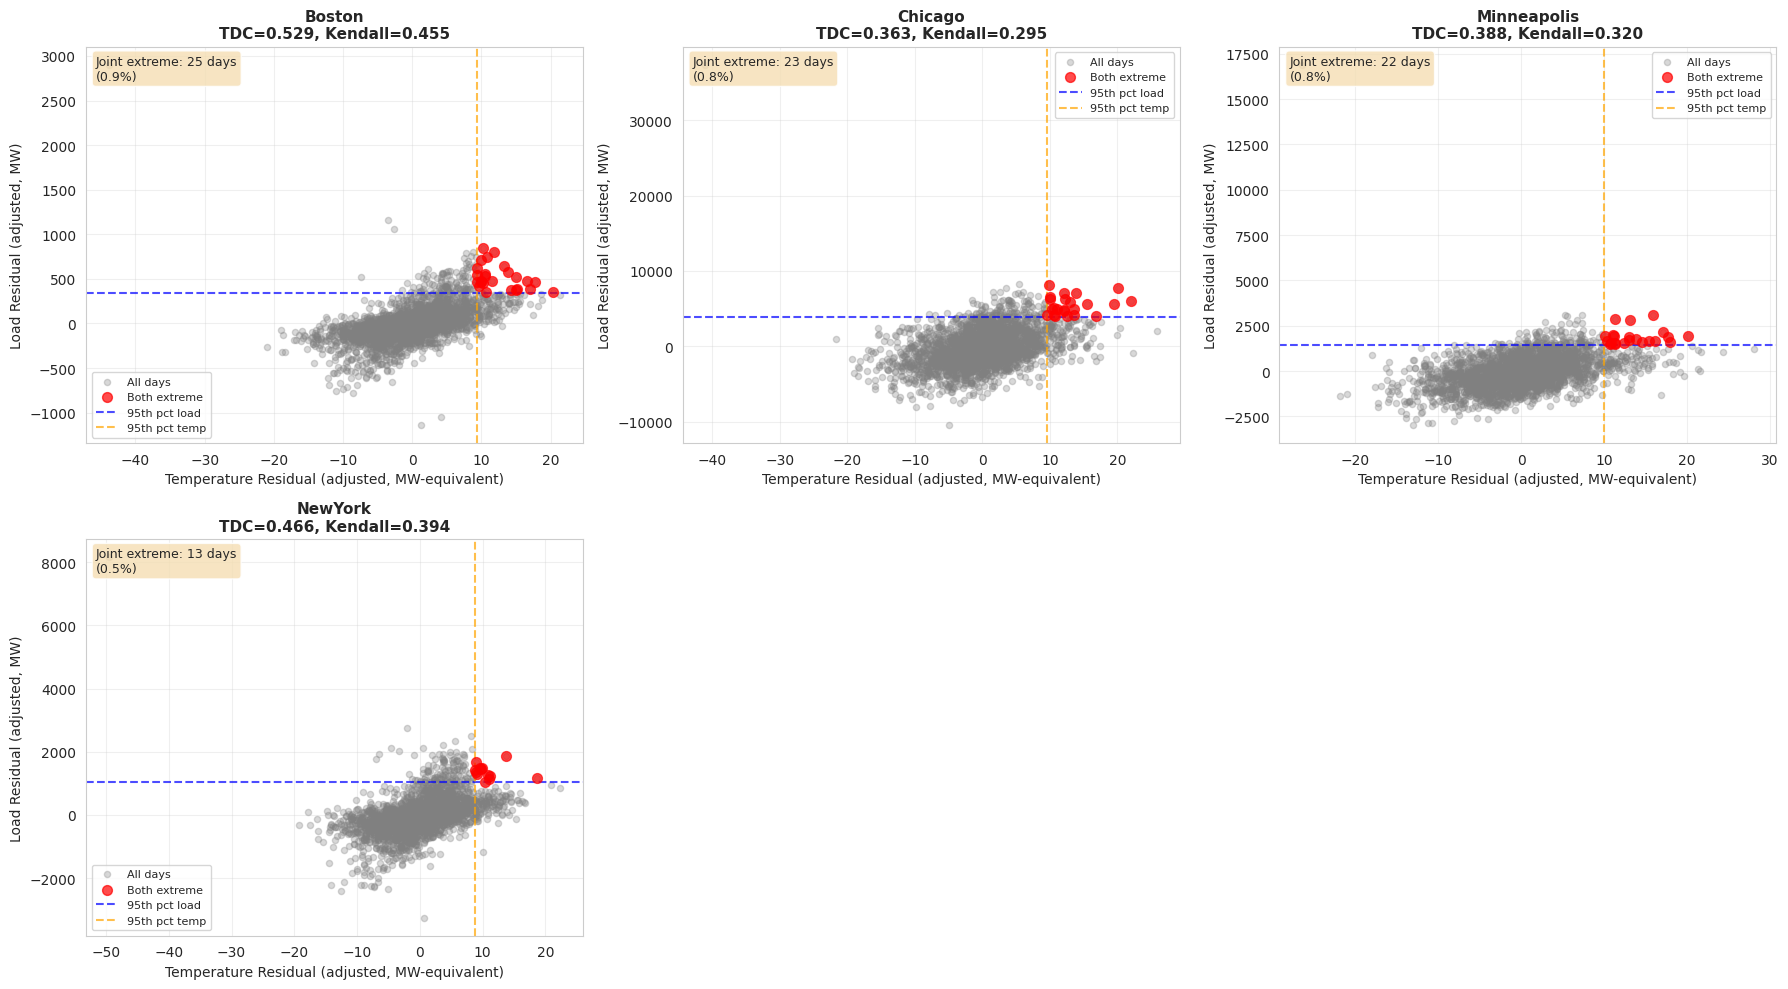

✓ Saved: ../data/images/load_temp_joint_tails.png


In [95]:
# Visualize joint tail behavior
print("="*80)
print("VISUALIZING TEMPERATURE-LOAD JOINT TAILS")
print("="*80)

n_cities = len(bivariate_results)
if n_cities == 0:
    print("⚠️  No cities to visualize")
else:
    # Create subplots
    n_cols = min(3, n_cities)
    n_rows = (n_cities + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_cities == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, (city, results) in enumerate(bivariate_results.items()):
        ax = axes[idx]
        
        data = results['data']
        
        # Scatter plot with threshold lines
        ax.scatter(data['temp'], data['load'], alpha=0.3, s=20, color='gray', label='All days')
        
        # Mark extreme points (95th percentile)
        temp_95 = data['temp'].quantile(0.95)
        load_95 = data['load'].quantile(0.95)
        
        # Color code quadrants
        both_extreme = (data['temp'] > temp_95) & (data['load'] > load_95)
        ax.scatter(data.loc[both_extreme, 'temp'], 
                  data.loc[both_extreme, 'load'], 
                  color='red', s=50, alpha=0.7, label='Both extreme', zorder=10)
        
        # Add threshold lines
        ax.axhline(load_95, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label=f'95th pct load')
        ax.axvline(temp_95, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label=f'95th pct temp')
        
        # Labels
        ax.set_xlabel('Temperature Residual (adjusted, MW-equivalent)', fontsize=10)
        ax.set_ylabel('Load Residual (adjusted, MW)', fontsize=10)
        ax.set_title(f'{city}\nTDC={results["tdc"]:.3f}, Kendall={results["kendall"]:.3f}', 
                    fontsize=11, fontweight='bold')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Add quadrant count
        n_both = both_extreme.sum()
        ax.text(0.02, 0.98, f'Joint extreme: {n_both} days\n({n_both/len(data)*100:.1f}%)',
               transform=ax.transAxes, fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Hide unused subplots
    for idx in range(n_cities, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('../data/images/load_temp_joint_tails.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: ../data/images/load_temp_joint_tails.png")

In [96]:
# Export temperature-load joint results
df_joint_exceedance.to_csv('../data/processed/temp_load_joint_exceedance.csv', index=False)
print("✓ Saved: ../data/processed/temp_load_joint_exceedance.csv")

# Create summary comparison table
print("\n" + "="*80)
print("TEMPERATURE-LOAD TAIL DEPENDENCE SUMMARY")
print("="*80)

summary_data = []
for city, results in bivariate_results.items():
    summary_data.append({
        'City': city,
        'N_days': results['n'],
        'Pearson_Corr': results['pearson'],
        'Kendall_Corr': results['kendall'],
        'TDC': results['tdc'],
        'Joint_95th': df_joint_exceedance[(df_joint_exceedance['City']==city) & 
                                         (df_joint_exceedance['Threshold']==0.95)]['P_both_exceed'].values[0],
        'Multiplier_95th': df_joint_exceedance[(df_joint_exceedance['City']==city) & 
                                              (df_joint_exceedance['Threshold']==0.95)]['Multiplier'].values[0]
    })

df_summary = pd.DataFrame(summary_data)
print("\nCity-level summary:")
display(df_summary.round(4))

df_summary.to_csv('../data/processed/temp_load_dependence_summary.csv', index=False)
print("\n✓ Saved: ../data/processed/temp_load_dependence_summary.csv")

print("\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)
print("""
Tail Dependence Coefficient (TDC):
  • 0.0 - 0.2: Weak tail dependence (extremes occur independently)
  • 0.2 - 0.5: Moderate tail dependence
  • 0.5 - 1.0: Strong tail dependence (extremes occur together)

Joint Exceedance Multiplier:
  • > 1.5: Strong positive dependence (extremes cluster)
  • 1.1 - 1.5: Moderate positive dependence
  • 0.9 - 1.1: Near independence
  • < 0.9: Negative dependence (extremes anti-correlated)

Practical Implications:
  • High TDC (>0.5): Extreme temperature → extreme load forecast errors
    → Need robust hedging strategies that account for joint extremes
  
  • Low TDC (<0.2): Temperature and load extremes occur independently
    → Can hedge temperature and load risks separately
  
  • Multiplier > 2: Joint extreme events 2x more likely than if independent
    → Significantly underestimating risk if assuming independence
""")

✓ Saved: ../data/processed/temp_load_joint_exceedance.csv

TEMPERATURE-LOAD TAIL DEPENDENCE SUMMARY

City-level summary:


,City,N_days,Pearson_Corr,Kendall_Corr,TDC,Joint_95th,Multiplier_95th
0,Boston,2737,0.5263,0.4548,0.5295,0.0088,3.5075
1,Chicago,2737,0.3672,0.2946,0.3629,0.0084,3.3613
2,Minneapolis,2737,0.4042,0.3197,0.3879,0.0080,3.2152
3,NewYork,2737,0.4315,0.3942,0.4664,0.0047,1.8999



✓ Saved: ../data/processed/temp_load_dependence_summary.csv

INTERPRETATION GUIDE

Tail Dependence Coefficient (TDC):
  • 0.0 - 0.2: Weak tail dependence (extremes occur independently)
  • 0.2 - 0.5: Moderate tail dependence
  • 0.5 - 1.0: Strong tail dependence (extremes occur together)

Joint Exceedance Multiplier:
  • > 1.5: Strong positive dependence (extremes cluster)
  • 1.1 - 1.5: Moderate positive dependence
  • 0.9 - 1.1: Near independence
  • < 0.9: Negative dependence (extremes anti-correlated)

Practical Implications:
  • High TDC (>0.5): Extreme temperature → extreme load forecast errors
    → Need robust hedging strategies that account for joint extremes

  • Low TDC (<0.2): Temperature and load extremes occur independently
    → Can hedge temperature and load risks separately

  • Multiplier > 2: Joint extreme events 2x more likely than if independent
    → Significantly underestimating risk if assuming independence



### Seasonal Analysis: HDD vs CDD Periods

Analyze temperature-load joint exceedance **separately** for heating (HDD) and cooling (CDD) seasons to identify if the relationship differs by season.

In [97]:
# Analyze HDD and CDD periods separately
print("="*80)
print("SEASONAL JOINT EXCEEDANCE ANALYSIS (HDD vs CDD)")
print("="*80)

seasonal_results = {'HDD': {}, 'CDD': {}}
seasonal_exceedance = []

for load_city in common_cities:
    temp_city = city_mapping[load_city]
    
    # Get aligned data (full dataset with all months)
    load_res = load_residuals_clean.loc[common_dates, load_city]
    temp_res = temp_residuals_adjusted.loc[common_dates, temp_city]
    
    # Create DataFrame and drop any NaN
    bivar_df = pd.DataFrame({
        'load': load_res,
        'temp': temp_res,
        'month': load_res.index.month
    }).dropna()
    
    if len(bivar_df) < 50:
        continue
    
    print(f"\n{'='*80}")
    print(f"{load_city.upper()}")
    print(f"{'='*80}")
    
    # Separate into HDD and CDD periods
    hdd_data = bivar_df[bivar_df['month'].isin(MONTH_HDD)].drop('month', axis=1)
    cdd_data = bivar_df[bivar_df['month'].isin(MONTH_CDD)].drop('month', axis=1)
    
    print(f"Total days: {len(bivar_df)}")
    print(f"  HDD days: {len(hdd_data)} (Nov-Mar)")
    print(f"  CDD days: {len(cdd_data)} (Jun-Aug)")
    
    # Analyze each season
    for season, season_data in [('HDD', hdd_data), ('CDD', cdd_data)]:
        if len(season_data) < 50:
            print(f"\n{season}: Insufficient data ({len(season_data)} days), skipping...")
            continue
        
        print(f"\n{season} Season Analysis:")
        print(f"  Sample size: {len(season_data)} days")
        
        # Transform to uniforms
        load_uniform = empirical_cdf_transform(season_data['load'].values)
        temp_uniform = empirical_cdf_transform(season_data['temp'].values)
        
        uniforms_df = pd.DataFrame({
            'load': load_uniform,
            'temp': temp_uniform
        })
        
        # Calculate correlations
        kendall_corr = uniforms_df.corr(method='kendall').loc['load', 'temp']
        pearson_corr = season_data.corr(method='pearson').loc['load', 'temp']
        
        print(f"  Pearson correlation:  {pearson_corr:.4f}")
        print(f"  Kendall correlation:  {kendall_corr:.4f}")
        
        # Calculate TDC
        tdc = ferreira_tail_dep_coeff(
            torch.tensor(load_uniform),
            torch.tensor(temp_uniform)
        )
        print(f"  Tail dependence (TDC): {tdc:.4f}")
        
        # Calculate 95th percentile joint exceedance
        threshold = 0.95
        both_exceed = ((uniforms_df['load'] > threshold) & (uniforms_df['temp'] > threshold)).mean()
        only_load = ((uniforms_df['load'] > threshold) & (uniforms_df['temp'] <= threshold)).mean()
        only_temp = ((uniforms_df['temp'] > threshold) & (uniforms_df['load'] <= threshold)).mean()
        
        # Under independence
        p_exceed = 1 - threshold
        indep_both = p_exceed ** 2
        multiplier = both_exceed / indep_both if indep_both > 0 else np.nan
        
        print(f"\n  95th Percentile Joint Exceedance:")
        print(f"    P(both exceed):      {both_exceed:.6f} ({both_exceed*len(season_data):.1f} days)")
        print(f"    P(only load):        {only_load:.6f}")
        print(f"    P(only temp):        {only_temp:.6f}")
        print(f"    Expected (indep):    {indep_both:.6f}")
        print(f"    Multiplier:          {multiplier:.2f}x")
        
        if multiplier > 1.5:
            print(f"    → ⚠️  STRONG joint tail risk in {season} season")
        elif multiplier > 1.1:
            print(f"    → Moderate joint tail risk in {season} season")
        else:
            print(f"    → Weak joint tail risk in {season} season")
        
        # Store results
        seasonal_results[season][load_city] = {
            'n': len(season_data),
            'pearson': pearson_corr,
            'kendall': kendall_corr,
            'tdc': tdc,
            'p_both_exceed': both_exceed,
            'multiplier': multiplier,
            'data': season_data,
            'uniforms': uniforms_df
        }
        
        seasonal_exceedance.append({
            'City': load_city,
            'Season': season,
            'N_days': len(season_data),
            'Pearson_Corr': pearson_corr,
            'Kendall_Corr': kendall_corr,
            'TDC': tdc,
            'P_both_exceed_95th': both_exceed,
            'Multiplier_95th': multiplier
        })

print("\n" + "="*80)
print("✓ Seasonal analysis complete")
print("="*80)

SEASONAL JOINT EXCEEDANCE ANALYSIS (HDD vs CDD)

BOSTON
Total days: 2737
  HDD days: 1360 (Nov-Mar)
  CDD days: 1377 (Jun-Aug)

HDD Season Analysis:
  Sample size: 1360 days
  Pearson correlation:  0.4244
  Kendall correlation:  0.4856
  Tail dependence (TDC): 0.5676

  95th Percentile Joint Exceedance:
    P(both exceed):      0.026471 (36.0 days)
    P(only load):        0.023529
    P(only temp):        0.023529
    Expected (indep):    0.002500
    Multiplier:          10.59x
    → ⚠️  STRONG joint tail risk in HDD season

CDD Season Analysis:
  Sample size: 1377 days
  Pearson correlation:  0.6824
  Kendall correlation:  0.4818
  Tail dependence (TDC): 0.5606

  95th Percentile Joint Exceedance:
    P(both exceed):      0.018882 (26.0 days)
    P(only load):        0.030501
    P(only temp):        0.030501
    Expected (indep):    0.002500
    Multiplier:          7.55x
    → ⚠️  STRONG joint tail risk in CDD season

CHICAGO
Total days: 2737
  HDD days: 1360 (Nov-Mar)
  CDD days:

In [98]:
# Create comparison table for HDD vs CDD
df_seasonal = pd.DataFrame(seasonal_exceedance)

print("="*80)
print("SEASONAL COMPARISON: HDD vs CDD")
print("="*80)

if len(df_seasonal) > 0:
    print("\nComplete seasonal results:")
    display(df_seasonal.round(4))
    
    # Pivot table for easier comparison
    print("\n" + "="*80)
    print("SIDE-BY-SIDE COMPARISON")
    print("="*80)
    
    for city in df_seasonal['City'].unique():
        city_data = df_seasonal[df_seasonal['City'] == city]
        
        print(f"\n{city}:")
        print(f"{'Metric':<30} {'HDD':<15} {'CDD':<15} {'Difference':<15}")
        print("-" * 75)
        
        hdd_row = city_data[city_data['Season'] == 'HDD']
        cdd_row = city_data[city_data['Season'] == 'CDD']
        
        if len(hdd_row) > 0 and len(cdd_row) > 0:
            metrics = ['N_days', 'Kendall_Corr', 'TDC', 'P_both_exceed_95th', 'Multiplier_95th']
            labels = ['Sample size', 'Kendall correlation', 'Tail dependence (TDC)', 
                     'P(both exceed 95th)', 'Multiplier']
            
            for metric, label in zip(metrics, labels):
                hdd_val = hdd_row[metric].values[0]
                cdd_val = cdd_row[metric].values[0]
                
                if metric == 'N_days':
                    diff = hdd_val - cdd_val
                    print(f"{label:<30} {hdd_val:<15.0f} {cdd_val:<15.0f} {diff:<+15.0f}")
                else:
                    diff = hdd_val - cdd_val
                    print(f"{label:<30} {hdd_val:<15.4f} {cdd_val:<15.4f} {diff:<+15.4f}")
            
            # Interpretation
            hdd_mult = hdd_row['Multiplier_95th'].values[0]
            cdd_mult = cdd_row['Multiplier_95th'].values[0]
            
            print(f"\n  Interpretation:")
            if hdd_mult > cdd_mult + 0.3:
                print(f"    → STRONGER joint tail risk in WINTER (HDD)")
                print(f"    → Temperature extremes MORE strongly coupled with load errors in winter")
            elif cdd_mult > hdd_mult + 0.3:
                print(f"    → STRONGER joint tail risk in SUMMER (CDD)")
                print(f"    → Temperature extremes MORE strongly coupled with load errors in summer")
            else:
                print(f"    → Similar joint tail risk in both seasons")
        elif len(hdd_row) > 0:
            print(f"  HDD only (no CDD data)")
        elif len(cdd_row) > 0:
            print(f"  CDD only (no HDD data)")
    
    # Export
    df_seasonal.to_csv('../data/processed/temp_load_seasonal_comparison.csv', index=False)
    print("\n" + "="*80)
    print("✓ Saved: ../data/processed/temp_load_seasonal_comparison.csv")
    print("="*80)
else:
    print("⚠️  No seasonal data available")

SEASONAL COMPARISON: HDD vs CDD

Complete seasonal results:


SEASONAL COMPARISON: HDD vs CDD

Complete seasonal results:


,City,Season,N_days,Pearson_Corr,Kendall_Corr,TDC,P_both_exceed_95th,Multiplier_95th
0,Boston,HDD,1360,0.4244,0.4856,0.5676,0.0265,10.5882
1,Boston,CDD,1377,0.6824,0.4818,0.5606,0.0189,7.5527
2,Chicago,HDD,1360,0.3303,0.2963,0.3726,0.0118,4.7059
3,Chicago,CDD,1377,0.4478,0.3040,0.3717,0.0073,2.9049
4,Minneapolis,HDD,1360,0.3589,0.3254,0.4029,0.0118,4.7059
5,Minneapolis,CDD,1377,0.5048,0.3390,0.4148,0.0145,5.8097
6,NewYork,HDD,1360,0.2618,0.3733,0.4697,0.0176,7.0588
7,NewYork,CDD,1377,0.6616,0.4821,0.5556,0.0131,5.2288



SIDE-BY-SIDE COMPARISON

Boston:
Metric                         HDD             CDD             Difference     
---------------------------------------------------------------------------
Sample size                    1360            1377            -17            
Kendall correlation            0.4856          0.4818          +0.0038        
Tail dependence (TDC)          0.5676          0.5606          +0.0070        
P(both exceed 95th)            0.0265          0.0189          +0.0076        
Multiplier                     10.5882         7.5527          +3.0356        

  Interpretation:
    → STRONGER joint tail risk in WINTER (HDD)
    → Temperature extremes MORE strongly coupled with load errors in winter

Chicago:
Metric                         HDD             CDD             Difference     
---------------------------------------------------------------------------
Sample size                    1360            1377            -17            
Kendall correlation           

VISUALIZING HDD vs CDD SEASONAL DIFFERENCES


VISUALIZING HDD vs CDD SEASONAL DIFFERENCES


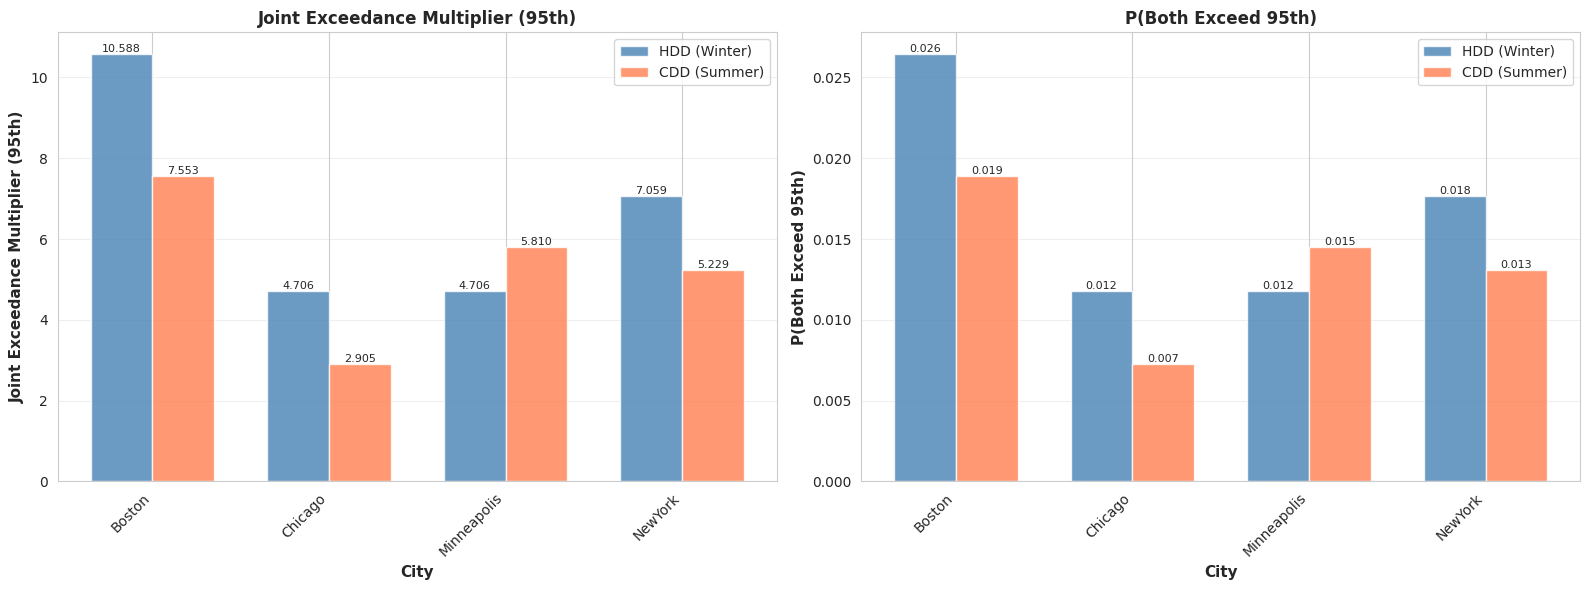

VISUALIZING HDD vs CDD SEASONAL DIFFERENCES


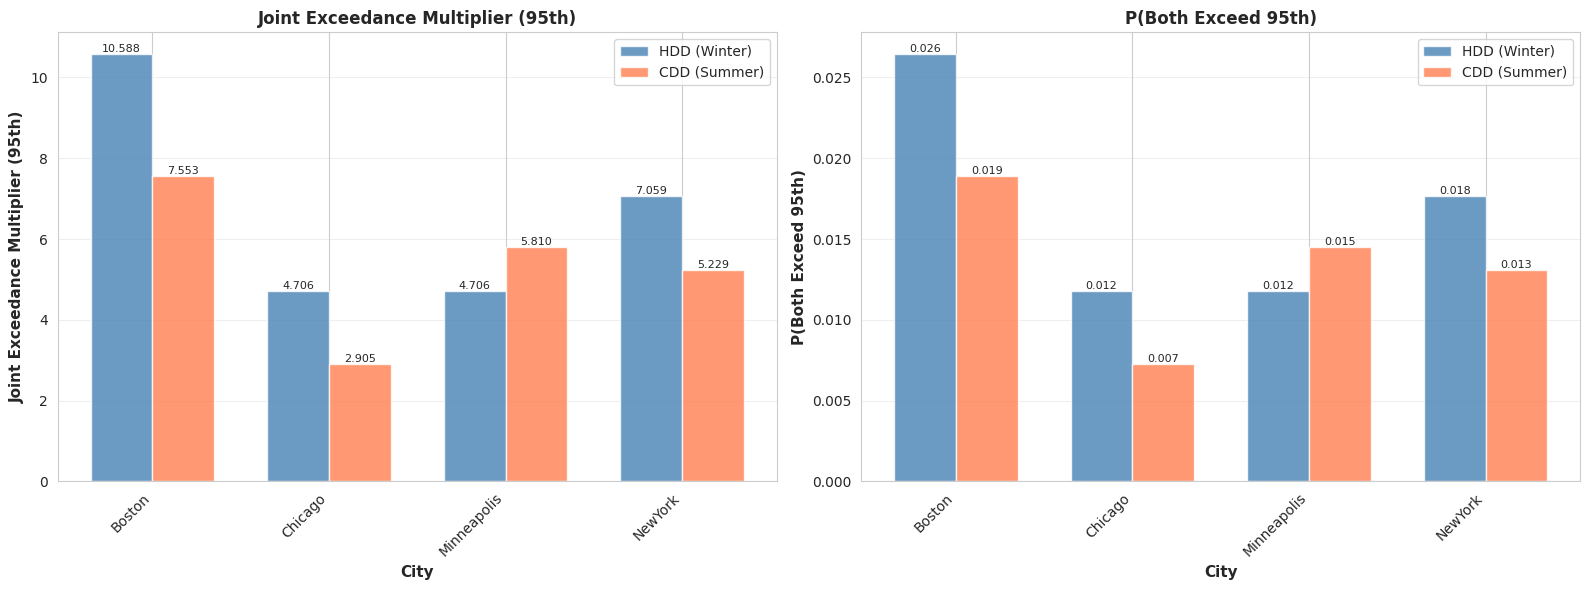

✓ Saved: ../data/images/hdd_cdd_comparison.png


VISUALIZING HDD vs CDD SEASONAL DIFFERENCES


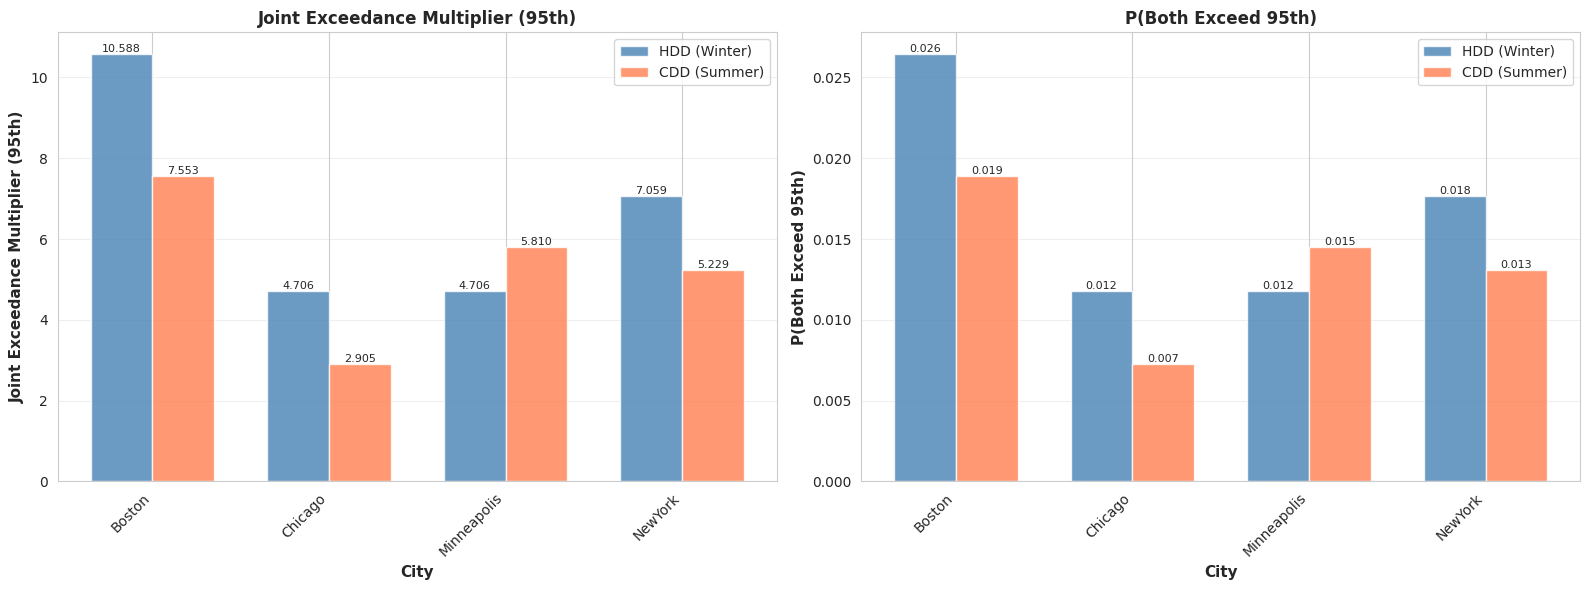

✓ Saved: ../data/images/hdd_cdd_comparison.png


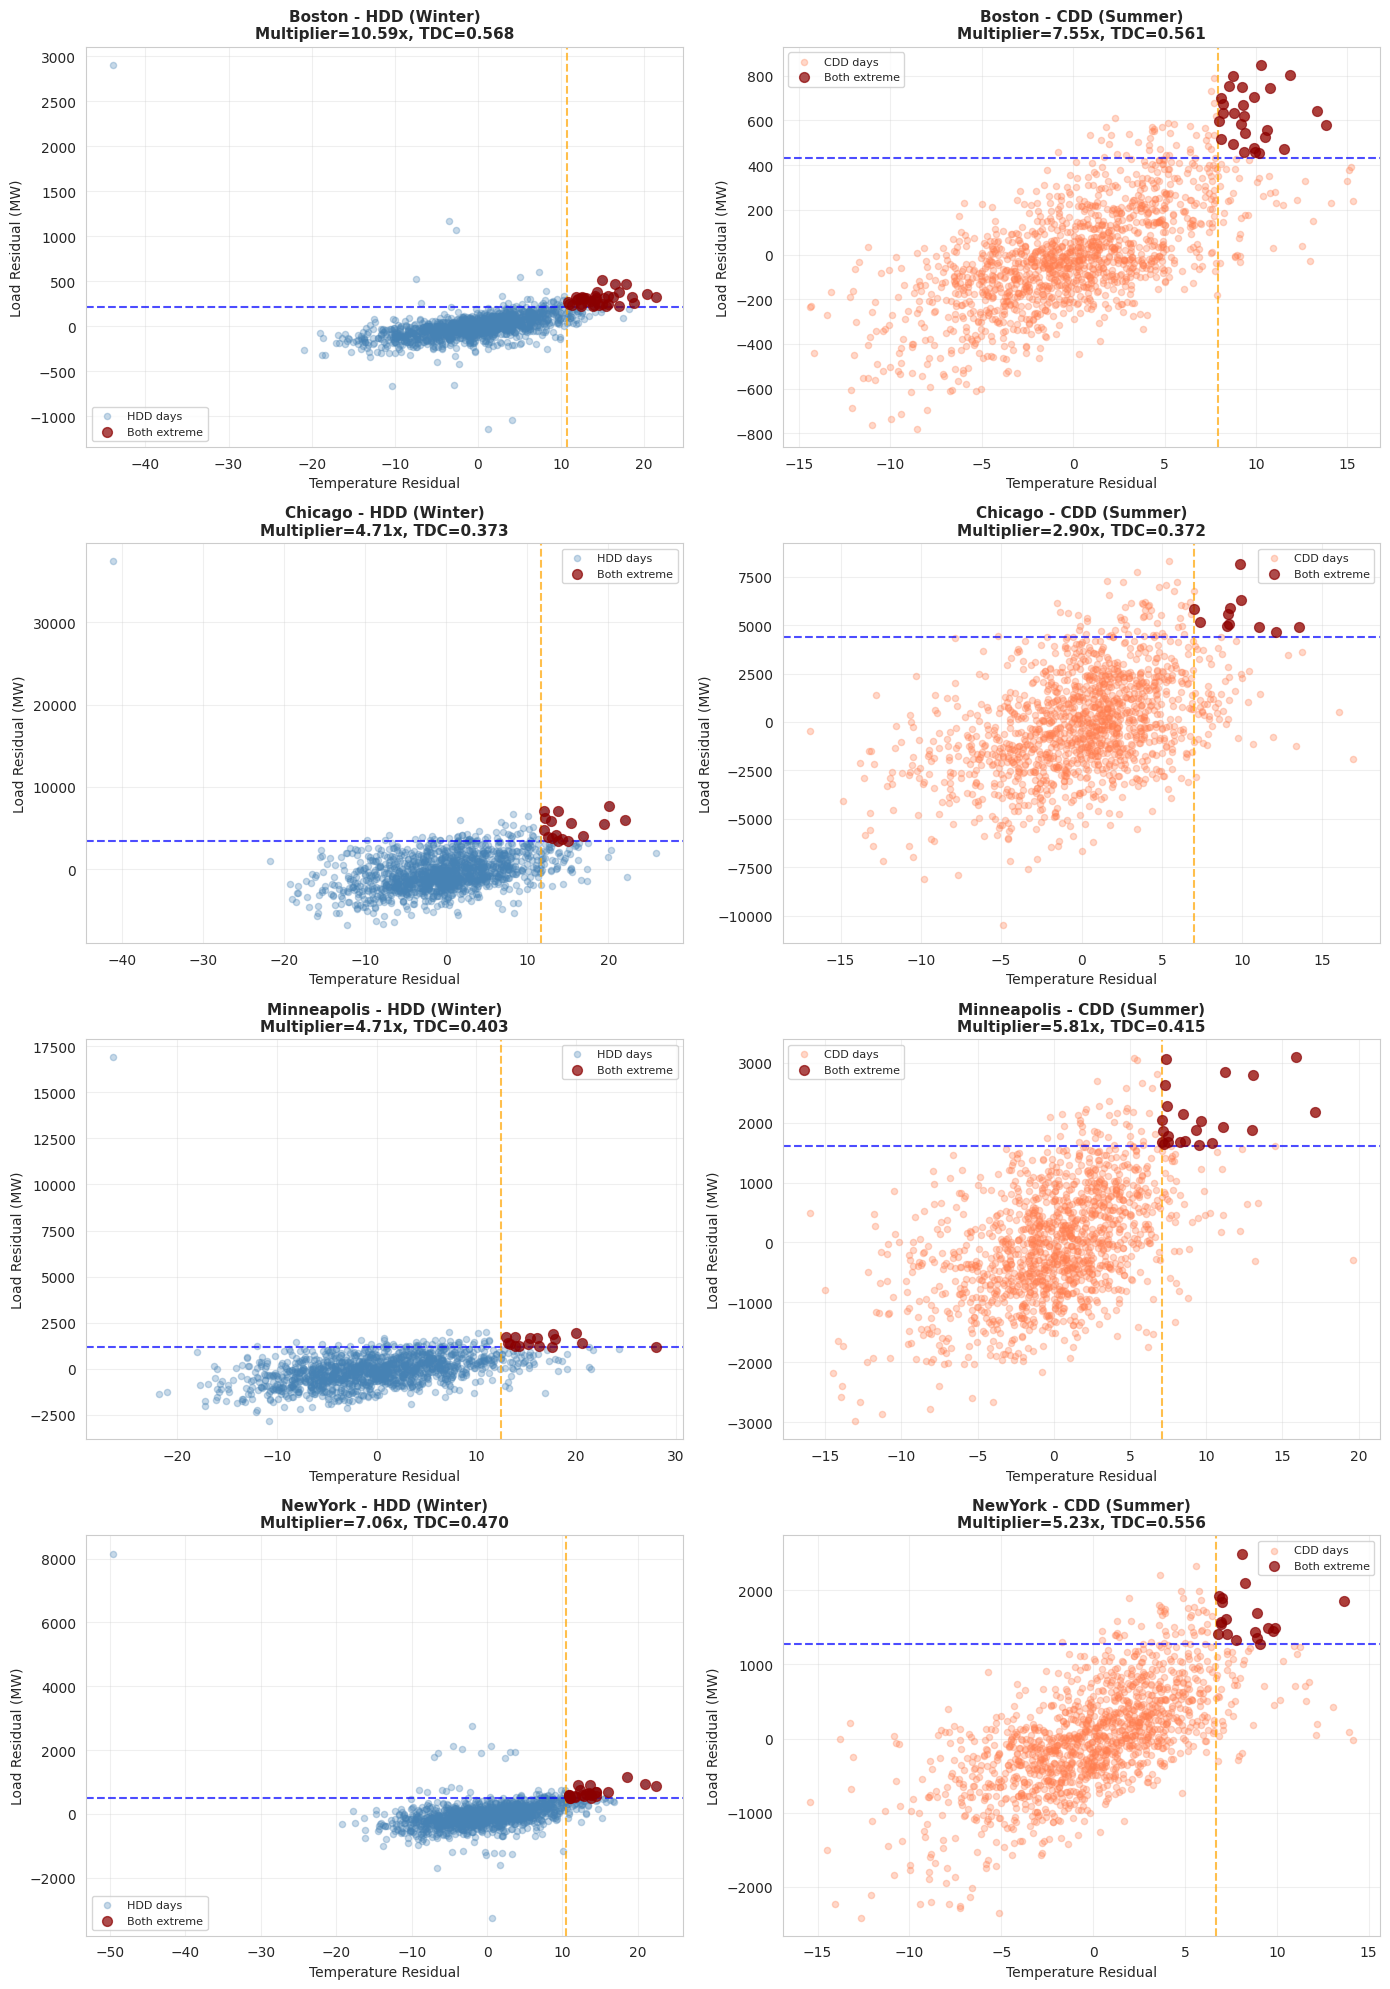

✓ Saved: ../data/images/hdd_cdd_scatter_comparison.png


In [99]:
# Visualize HDD vs CDD comparison
print("="*80)
print("VISUALIZING HDD vs CDD SEASONAL DIFFERENCES")
print("="*80)

if len(df_seasonal) > 0:
    # Create comparison bar charts
    cities_with_both = []
    for city in df_seasonal['City'].unique():
        city_data = df_seasonal[df_seasonal['City'] == city]
        if len(city_data[city_data['Season'] == 'HDD']) > 0 and len(city_data[city_data['Season'] == 'CDD']) > 0:
            cities_with_both.append(city)
    
    if len(cities_with_both) > 0:
        # Only show joint probability and exceedance metrics (TDC and Kendall in other notebook)
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        metrics = ['Multiplier_95th', 'P_both_exceed_95th']
        titles = ['Joint Exceedance Multiplier (95th)', 
                 'P(Both Exceed 95th)']
        
        for idx, (metric, title) in enumerate(zip(metrics, titles)):
            ax = axes[idx]
            
            hdd_vals = []
            cdd_vals = []
            
            for city in cities_with_both:
                hdd_row = df_seasonal[(df_seasonal['City'] == city) & (df_seasonal['Season'] == 'HDD')]
                cdd_row = df_seasonal[(df_seasonal['City'] == city) & (df_seasonal['Season'] == 'CDD')]
                
                if len(hdd_row) > 0 and len(cdd_row) > 0:
                    hdd_vals.append(hdd_row[metric].values[0])
                    cdd_vals.append(cdd_row[metric].values[0])
            
            x = np.arange(len(cities_with_both))
            width = 0.35
            
            bars1 = ax.bar(x - width/2, hdd_vals, width, label='HDD (Winter)', color='steelblue', alpha=0.8)
            bars2 = ax.bar(x + width/2, cdd_vals, width, label='CDD (Summer)', color='coral', alpha=0.8)
            
            ax.set_xlabel('City', fontsize=11, fontweight='bold')
            ax.set_ylabel(title, fontsize=11, fontweight='bold')
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(cities_with_both, rotation=45, ha='right')
            ax.legend()
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add value labels on bars
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    if not np.isnan(height):
                        ax.text(bar.get_x() + bar.get_width()/2., height,
                               f'{height:.3f}',
                               ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.savefig('../data/images/hdd_cdd_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ Saved: ../data/images/hdd_cdd_comparison.png")
        
        # Scatter plots for each city (HDD vs CDD side-by-side)
        n_cities = len(cities_with_both)
        fig, axes = plt.subplots(n_cities, 2, figsize=(14, 5*n_cities))
        
        if n_cities == 1:
            axes = axes.reshape(1, -1)
        
        for idx, city in enumerate(cities_with_both):
            # HDD plot
            ax_hdd = axes[idx, 0]
            if 'HDD' in seasonal_results and city in seasonal_results['HDD']:
                data_hdd = seasonal_results['HDD'][city]['data']
                temp_95 = data_hdd['temp'].quantile(0.95)
                load_95 = data_hdd['load'].quantile(0.95)
                both_extreme = (data_hdd['temp'] > temp_95) & (data_hdd['load'] > load_95)
                
                ax_hdd.scatter(data_hdd['temp'], data_hdd['load'], alpha=0.3, s=20, color='steelblue', label='HDD days')
                ax_hdd.scatter(data_hdd.loc[both_extreme, 'temp'], 
                              data_hdd.loc[both_extreme, 'load'], 
                              color='darkred', s=50, alpha=0.7, label='Both extreme', zorder=10)
                ax_hdd.axhline(load_95, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
                ax_hdd.axvline(temp_95, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
                ax_hdd.set_xlabel('Temperature Residual', fontsize=10)
                ax_hdd.set_ylabel('Load Residual (MW)', fontsize=10)
                
                mult = seasonal_results['HDD'][city]['multiplier']
                tdc = seasonal_results['HDD'][city]['tdc']
                ax_hdd.set_title(f'{city} - HDD (Winter)\nMultiplier={mult:.2f}x, TDC={tdc:.3f}', 
                                fontsize=11, fontweight='bold')
                ax_hdd.legend(loc='best', fontsize=8)
                ax_hdd.grid(True, alpha=0.3)
            
            # CDD plot
            ax_cdd = axes[idx, 1]
            if 'CDD' in seasonal_results and city in seasonal_results['CDD']:
                data_cdd = seasonal_results['CDD'][city]['data']
                temp_95 = data_cdd['temp'].quantile(0.95)
                load_95 = data_cdd['load'].quantile(0.95)
                both_extreme = (data_cdd['temp'] > temp_95) & (data_cdd['load'] > load_95)
                
                ax_cdd.scatter(data_cdd['temp'], data_cdd['load'], alpha=0.3, s=20, color='coral', label='CDD days')
                ax_cdd.scatter(data_cdd.loc[both_extreme, 'temp'], 
                              data_cdd.loc[both_extreme, 'load'], 
                              color='darkred', s=50, alpha=0.7, label='Both extreme', zorder=10)
                ax_cdd.axhline(load_95, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
                ax_cdd.axvline(temp_95, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
                ax_cdd.set_xlabel('Temperature Residual', fontsize=10)
                ax_cdd.set_ylabel('Load Residual (MW)', fontsize=10)
                
                mult = seasonal_results['CDD'][city]['multiplier']
                tdc = seasonal_results['CDD'][city]['tdc']
                ax_cdd.set_title(f'{city} - CDD (Summer)\nMultiplier={mult:.2f}x, TDC={tdc:.3f}', 
                                fontsize=11, fontweight='bold')
                ax_cdd.legend(loc='best', fontsize=8)
                ax_cdd.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('../data/images/hdd_cdd_scatter_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("✓ Saved: ../data/images/hdd_cdd_scatter_comparison.png")
    else:
        print("⚠️  No cities with both HDD and CDD data for visualization")
else:
    print("⚠️  No seasonal data to visualize")

In [ ]:
# Summary insights: HDD vs CDD
print("="*80)
print("KEY INSIGHTS: HDD vs CDD SEASONAL DIFFERENCES")
print("="*80)

if len(df_seasonal) > 0:
    for city in df_seasonal['City'].unique():
        hdd_row = df_seasonal[(df_seasonal['City'] == city) & (df_seasonal['Season'] == 'HDD')]
        cdd_row = df_seasonal[(df_seasonal['City'] == city) & (df_seasonal['Season'] == 'CDD')]
        
        if len(hdd_row) > 0 and len(cdd_row) > 0:
            print(f"\n{'='*80}")
            print(f"{city.upper()}")
            print(f"{'='*80}")
            
            hdd_mult = hdd_row['Multiplier_95th'].values[0]
            cdd_mult = cdd_row['Multiplier_95th'].values[0]
            hdd_tdc = hdd_row['TDC'].values[0]
            cdd_tdc = cdd_row['TDC'].values[0]
            
            print(f"\nWinter (HDD):")
            print(f"  • Multiplier: {hdd_mult:.2f}x {'[STRONG]' if hdd_mult > 1.5 else '[MODERATE]' if hdd_mult > 1.1 else '[WEAK]'}")
            print(f"  • TDC: {hdd_tdc:.3f}")
            print(f"  • Sample: {hdd_row['N_days'].values[0]:.0f} days")
            
            print(f"\nSummer (CDD):")
            print(f"  • Multiplier: {cdd_mult:.2f}x {'[STRONG]' if cdd_mult > 1.5 else '[MODERATE]' if cdd_mult > 1.1 else '[WEAK]'}")
            print(f"  • TDC: {cdd_tdc:.3f}")
            print(f"  • Sample: {cdd_row['N_days'].values[0]:.0f} days")
            
            diff_mult = hdd_mult - cdd_mult
            diff_tdc = hdd_tdc - cdd_tdc
            

    # Overall summary
    print(f"\n{'='*80}")
    print("OVERALL SUMMARY")
    print(f"{'='*80}")
    
    avg_hdd_mult = df_seasonal[df_seasonal['Season'] == 'HDD']['Multiplier_95th'].mean()
    avg_cdd_mult = df_seasonal[df_seasonal['Season'] == 'CDD']['Multiplier_95th'].mean()
    avg_hdd_tdc = df_seasonal[df_seasonal['Season'] == 'HDD']['TDC'].mean()
    avg_cdd_tdc = df_seasonal[df_seasonal['Season'] == 'CDD']['TDC'].mean()
    
    print(f"\nAverage across all cities:")
    print(f"  HDD (Winter): Multiplier={avg_hdd_mult:.2f}x, TDC={avg_hdd_tdc:.3f}")
    print(f"  CDD (Summer): Multiplier={avg_cdd_mult:.2f}x, TDC={avg_cdd_tdc:.3f}")
    print(f"  Difference:   Multiplier={avg_hdd_mult-avg_cdd_mult:+.2f}x, TDC={avg_hdd_tdc-avg_cdd_tdc:+.3f}")
    
    if avg_hdd_mult > avg_cdd_mult + 0.3:
        print(f"\n🎯 CONCLUSION: WINTER (HDD) has systematically STRONGER joint tail risk")
        print(f"   → Temperature-load coupling is more critical in heating season")
    elif avg_cdd_mult > avg_hdd_mult + 0.3:
        print(f"\n🎯 CONCLUSION: SUMMER (CDD) has systematically STRONGER joint tail risk")
        print(f"   → Temperature-load coupling is more critical in cooling season")
    else:
        print(f"\n🎯 CONCLUSION: Both seasons show SIMILAR joint tail risk")
        print(f"   → Temperature-load coupling consistent across heating and cooling")

print("\n" + "="*80)
print("✓ SEASONAL ANALYSIS COMPLETE")
print("="*80)

KEY INSIGHTS: HDD vs CDD SEASONAL DIFFERENCES

BOSTON

Winter (HDD):
  • Multiplier: 10.59x [STRONG]
  • TDC: 0.568
  • Sample: 1360 days

Summer (CDD):
  • Multiplier: 7.55x [STRONG]
  • TDC: 0.561
  • Sample: 1377 days

📊 Comparison:
  ⚠️  WINTER shows 3.04x HIGHER joint tail risk
      → Temperature extremes MORE strongly predict load forecast errors in winter
      → Heating season requires more robust hedging strategies

CHICAGO

Winter (HDD):
  • Multiplier: 4.71x [STRONG]
  • TDC: 0.373
  • Sample: 1360 days

Summer (CDD):
  • Multiplier: 2.90x [STRONG]
  • TDC: 0.372
  • Sample: 1377 days

📊 Comparison:
  ⚠️  WINTER shows 1.80x HIGHER joint tail risk
      → Temperature extremes MORE strongly predict load forecast errors in winter
      → Heating season requires more robust hedging strategies

MINNEAPOLIS

Winter (HDD):
  • Multiplier: 4.71x [STRONG]
  • TDC: 0.403
  • Sample: 1360 days

Summer (CDD):
  • Multiplier: 5.81x [STRONG]
  • TDC: 0.415
  • Sample: 1377 days

📊 Compar

## V. Export Results

In [101]:
# Export GPD parameters
print("="*80)
print("EXPORTING RESULTS")
print("="*80)

# 1. Right tail GPD parameters (95th percentile only)
gpd_right_export = []
for city in cities:
    params = gpd_params_right[city]['q95']
    gpd_right_export.append({
        'City': city,
        'Tail': 'Right',
        'Quantile': 'q95',
        'xi': params['xi'],
        'sigma': params['sigma'],
        'threshold': params['u'],
        'lambda': params['lambda'],
        'n_exceedances': params['n']
    })

pd.DataFrame(gpd_right_export).to_csv('../data/processed/load_residuals_gpd_right_tail.csv', index=False)
print("✓ Saved: load_residuals_gpd_right_tail.csv")

# 2. Left tail GPD parameters (95th percentile only)
gpd_left_export = []
for city in cities:
    params = gpd_params_left[city]['q95']
    gpd_left_export.append({
        'City': city,
        'Tail': 'Left',
        'Quantile': 'q95',
        'xi': params['xi'],
        'sigma': params['sigma'],
        'threshold': params['u'],
        'lambda': params['lambda'],
        'n_exceedances': params['n']
    })

pd.DataFrame(gpd_left_export).to_csv('../data/processed/load_residuals_gpd_left_tail.csv', index=False)
print("✓ Saved: load_residuals_gpd_left_tail.csv")

# 3. Joint tail probabilities
joint_probs = []
for threshold in [0.90, 0.95, 0.99]:
    all_exceed = (simulated_df > threshold).all(axis=1).mean()
    any_exceed = (simulated_df > threshold).any(axis=1).mean()
    n_exceed = (simulated_df > threshold).sum(axis=1)
    
    joint_probs.append({
        'Threshold': threshold,
        f'P_all_{len(cities)}_exceed': all_exceed,
        'P_any_exceed': any_exceed,
        'P_exactly_2': (n_exceed==2).mean() if len(cities) >= 2 else np.nan,
        'P_exactly_3': (n_exceed==3).mean() if len(cities) >= 3 else np.nan
    })

pd.DataFrame(joint_probs).to_csv('../data/processed/load_residuals_joint_tail_probabilities.csv', index=False)


EXPORTING RESULTS
✓ Saved: load_residuals_gpd_right_tail.csv
✓ Saved: load_residuals_gpd_left_tail.csv
